# Tau-5* master ASTEROIDS-style ensemble analysis
**Snapshot: 29 September 2026.** WT and W397A/W433A (AA), first base and expanded candidate pools, with all three equal-weight selections per condition.

This notebook shows pre/post **subset selection**, not continuous reweighting. Every selected ensemble contains 500 distinct structures, weight 1/500. Seeds repeat optimization of the same pool; they are not independent pool-generation replicates. The method is our custom ASTEROIDS-style implementation, not the original software.

**Navigation:** [Summary tables](#summary-tables) · [SAXS low-q weighting](#saxs-low-q-weighting) · [WT base](#wt-base) · [WT expanded](#wt-expanded) · [AA base](#aa-base) · [AA expanded](#aa-expanded) · [Definitions and references](#definitions-and-references)

For each condition: full SAXS/low-q/residual diagnostics; full-sequence and R2–R3 helicity; secondary shifts; signed/absolute shift residuals; Sα–Rg distributions; contact maps; Sα and helix-length histograms. Full-chain figures show raw plus all three selections; R2–R3 structural figures also show the **57,144-frame 2022 apo WT MD**.

The MD simulation models a shorter capped construct. Only AR391–446 is compared; full-chain experimental CS/SAXS fits are not assigned to the short MD construct. MD frames are uniformly weighted, with no additional equilibration exclusion. GP + AR330–447 is retained in generated full chains. No Ramachandran-basin analysis is included.

**Re-run:** keep `analysis.py` and `data/` beside this notebook. Plotting requires NumPy, pandas, matplotlib and seaborn; cached structural data make trajectories unnecessary for replotting. `master_compute.py` documents regeneration from original trajectory inputs. The downloadable bundle contains all these files and the numerical summary tables.

In [1]:
from analysis import *
print("Conditions:", ", ".join(META["conditions"]))
print("MD frames:", len(MD["values"]))

Conditions: WT_base, WT_expanded, AA_base, AA_expanded
MD frames: 57144


## Summary tables
Rg and Sα are **mean ± ensemble population SD** (ddof=0), not standard errors. Rg is Cα geometric Rg, in nm. RMSDs are computed separately for each available nucleus (ppm); `C` means carbonyl C′, `NH` means HN. Missing nuclei are not imputed.

For sequence-separation threshold s, mean tertiary contact population is

**P_s = [1/N_pairs(s)] Σ_(i<j, |i−j|>s) ⟨1[d_ij<1.2 nm]⟩.**

The denominator includes all eligible unique residue pairs, including pairs that never contact. It is **not** the probability of having any contact. The numerical CSV also reports the expected number of contacts and pair count. Thresholds are strictly >5, >10 and >20.

The full-chain table contains whole-construct CS RMSDs and SAXS χ²/point. The R2–R3 table contains CS RMSDs restricted to AR391–446; SAXS metrics are deliberately omitted for this cropped segment. MD experimental-fit columns are unavailable because no matching-construct fit is being claimed. SAXS intensity RMSD and all unrounded statistics are in `ensemble_summary.csv`.

In [2]:
display(summary_table("full"))
display(summary_table("R2R3"))
SUMMARY.to_csv("ensemble_summary.csv", index=False)
QSUMMARY.to_csv("saxs_q_region_summary.csv", index=False)

ensemble,n,CA RMSD (ppm),C RMSD (ppm),CB RMSD (ppm),N RMSD (ppm),NH RMSD (ppm),SAXS χ²/point,Rg ± SD (nm),Sα ± SD,"P(contact), |i−j|>5","P(contact), |i−j|>10","P(contact), |i−j|>20"
WT_base_raw,2000,0.383,0.502,—,0.789,0.217,20.763,3.342 ± 0.705,4.212 ± 2.515,0.0589,0.0282,0.0139
WT_base_ens1,500,0.307,0.424,—,0.779,0.218,7.924,3.208 ± 0.810,5.270 ± 2.739,0.0704,0.0382,0.0228
WT_base_ens2,500,0.300,0.420,—,0.792,0.219,7.943,3.220 ± 0.805,5.467 ± 2.774,0.0701,0.0378,0.0225
WT_base_ens3,500,0.306,0.428,—,0.780,0.217,7.735,3.199 ± 0.772,5.215 ± 2.686,0.0705,0.0385,0.0229
WT_expanded_raw,2110,0.376,0.496,—,0.787,0.217,20.776,3.343 ± 0.703,4.355 ± 2.628,0.0590,0.0281,0.0138
WT_expanded_ens1,500,0.303,0.417,—,0.773,0.218,7.337,3.206 ± 0.801,5.550 ± 2.890,0.0711,0.0391,0.0236
WT_expanded_ens2,500,0.297,0.416,—,0.778,0.218,7.403,3.200 ± 0.814,5.644 ± 2.978,0.0709,0.0388,0.0235
WT_expanded_ens3,500,0.296,0.420,—,0.763,0.217,7.898,3.204 ± 0.795,5.539 ± 2.975,0.0705,0.0383,0.0230
AA_base_raw,2000,0.396,0.493,0.344,1.353,0.165,6.859,3.274 ± 0.684,4.442 ± 2.607,0.0614,0.0296,0.0143
AA_base_ens1,500,0.310,0.403,0.295,1.324,0.155,2.851,3.177 ± 0.645,5.909 ± 2.908,0.0636,0.0312,0.0167


ensemble,n,CA RMSD (ppm),C RMSD (ppm),CB RMSD (ppm),N RMSD (ppm),NH RMSD (ppm),Rg ± SD (nm),Sα ± SD,"P(contact), |i−j|>5","P(contact), |i−j|>10","P(contact), |i−j|>20"
WT_base_raw,2000,0.431,0.523,—,0.656,0.189,1.925 ± 0.351,2.931 ± 2.322,0.1437,0.0675,0.0323
WT_base_ens1,500,0.320,0.419,—,0.630,0.188,1.812 ± 0.346,3.787 ± 2.592,0.1645,0.0847,0.0472
WT_base_ens2,500,0.302,0.413,—,0.659,0.190,1.815 ± 0.346,3.949 ± 2.621,0.1651,0.0843,0.0454
WT_base_ens3,500,0.320,0.424,—,0.637,0.188,1.788 ± 0.331,3.706 ± 2.522,0.1687,0.0888,0.0498
WT_expanded_raw,2110,0.419,0.513,—,0.652,0.188,1.927 ± 0.351,3.064 ± 2.427,0.1437,0.0671,0.0319
WT_expanded_ens1,500,0.308,0.411,—,0.624,0.191,1.794 ± 0.349,4.005 ± 2.689,0.1675,0.0881,0.0511
WT_expanded_ens2,500,0.304,0.412,—,0.618,0.190,1.811 ± 0.366,4.039 ± 2.742,0.1656,0.0862,0.0496
WT_expanded_ens3,500,0.310,0.413,—,0.619,0.190,1.817 ± 0.355,3.994 ± 2.761,0.1634,0.0837,0.0466
AA_base_raw,2000,0.411,0.529,0.277,1.275,0.146,1.873 ± 0.339,3.093 ± 2.377,0.1505,0.0717,0.0336
AA_base_ens1,500,0.299,0.405,0.210,1.267,0.135,1.826 ± 0.337,4.306 ± 2.658,0.1563,0.0760,0.0401


## SAXS low-q weighting
**Literature check:** no explicit generic Guinier-upweighting rule was identified in the checked ASTEROIDS methods. [Huang et al. (2014)](https://doi.org/10.1021/ja502030n) use experimental SAXS errors and calculate 132 points through q≈0.2508 Å⁻¹ for their experimental range. [Schwalbe et al. (2014)](https://doi.org/10.1016/j.str.2013.10.020) describe CRYSOL ensemble averages and genetic subset selection without specifying a special low-q multiplier in the main methods. This does not establish that every ASTEROIDS implementation treats q identically. In [Naudi-Fabra et al. (2021)](https://pmc.ncbi.nlm.nih.gov/articles/PMC8662727/), SAXS and extended-Guinier Rg were independent validation of an NMR/FRET-selected ensemble.

Our current objective sums **[(a Icalc(q)−Iexp(q))/σ(q)]²** over all fitted q points, without regional normalization or an extra Guinier weight. The number of points and their uncertainties therefore influence each region's contribution.

The following table partitions the existing objective into q<0.04, 0.04–0.10, 0.10–0.25 and q≥0.25 Å⁻¹. These are diagnostic bands, **not assertions that q<0.04 is a validated Guinier window**. Plots also show cumulative χ² and ln I versus q². The displayed low-q Rg is a weighted straight-line diagnostic over q≤0.03 Å⁻¹ (weights I/σ); inspect curvature and qmax·Rg before interpreting it. It is not the Cα Rg.

Low-q agreement is essential for overall size. Intermediate/high-q data still distinguish shapes and internal organization. A future controlled comparison could use **J_SAXS = λ_low χ²_low/N_low + λ_rest χ²_rest/N_rest**, with a separately documented total SAXS/CS balance, or restrict the fitting range and validate the withheld tail. Neither change has been applied here. Adding Rg as if independent of the same fitted SAXS curve would double-count information.

In [3]:
display(QSUMMARY.round(4))

ensemble,q_start_Ainv,q_end_Ainv,n_points,chi2_sum,chi2_per_point,fraction_total_chi2
WT_base_raw,0.00,0.04,28,1063.1057,37.9681,0.3556
WT_base_raw,0.04,0.10,35,1162.3661,33.2105,0.3888
WT_base_raw,0.10,0.25,30,566.1744,18.8725,0.1894
WT_base_raw,0.25,inf,51,198.2055,3.8864,0.0663
WT_base_ens1,0.00,0.04,28,462.5393,16.5193,0.4054
WT_base_ens1,0.04,0.10,35,305.0846,8.7167,0.2674
WT_base_ens1,0.10,0.25,30,278.1853,9.2728,0.2438
WT_base_ens1,0.25,inf,51,95.2174,1.8670,0.0834
WT_base_ens2,0.00,0.04,28,468.9619,16.7486,0.4100
WT_base_ens2,0.04,0.10,35,300.3523,8.5815,0.2626


## WT base
Raw candidate pool versus all three 500-member selections. Ens1/2/3 correspond to optimizer seeds20260929/20261029/20261129. The MD comparator is always apo WT R2–R3, including in AA panels; it is not an AA simulation.

### SAXS before and after fitting
Each curve uses its own optimized nonnegative intensity scale; background is fixed to zero. Low-q slope annotations are diagnostic, not a separate restraint.

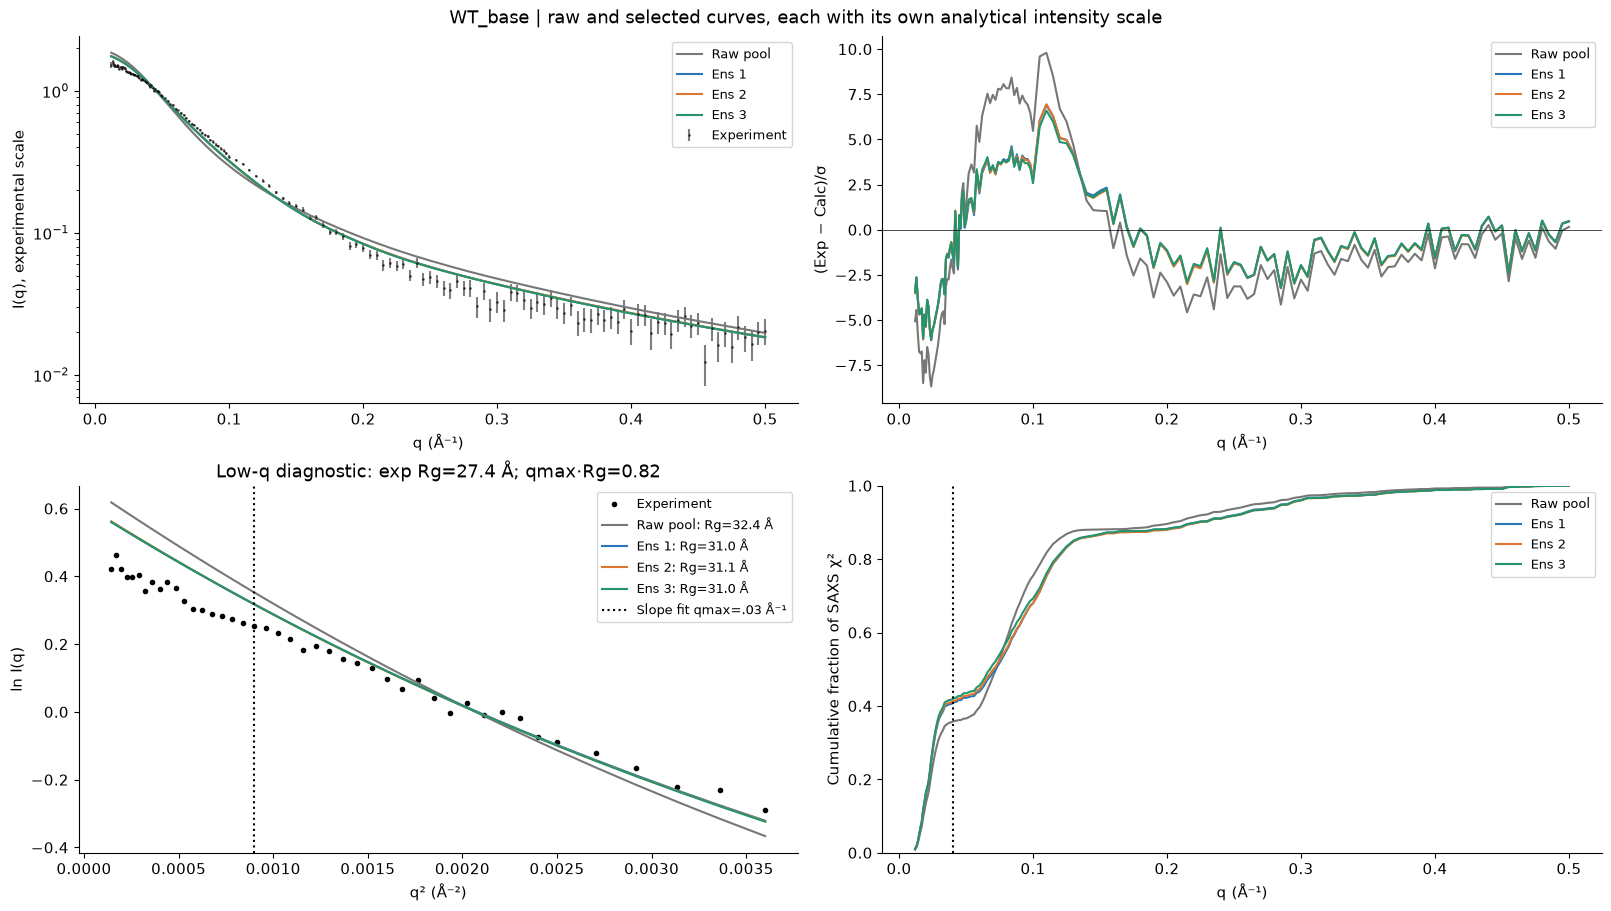

In [4]:
saxs("WT_base")

### Helix before and after selection
DSSP H and δ2D are distinct observables. Display excludes the added GP and terminal P447, as in earlier profiles. MD DSSP is calculated on the 56-residue core with caps excluded.

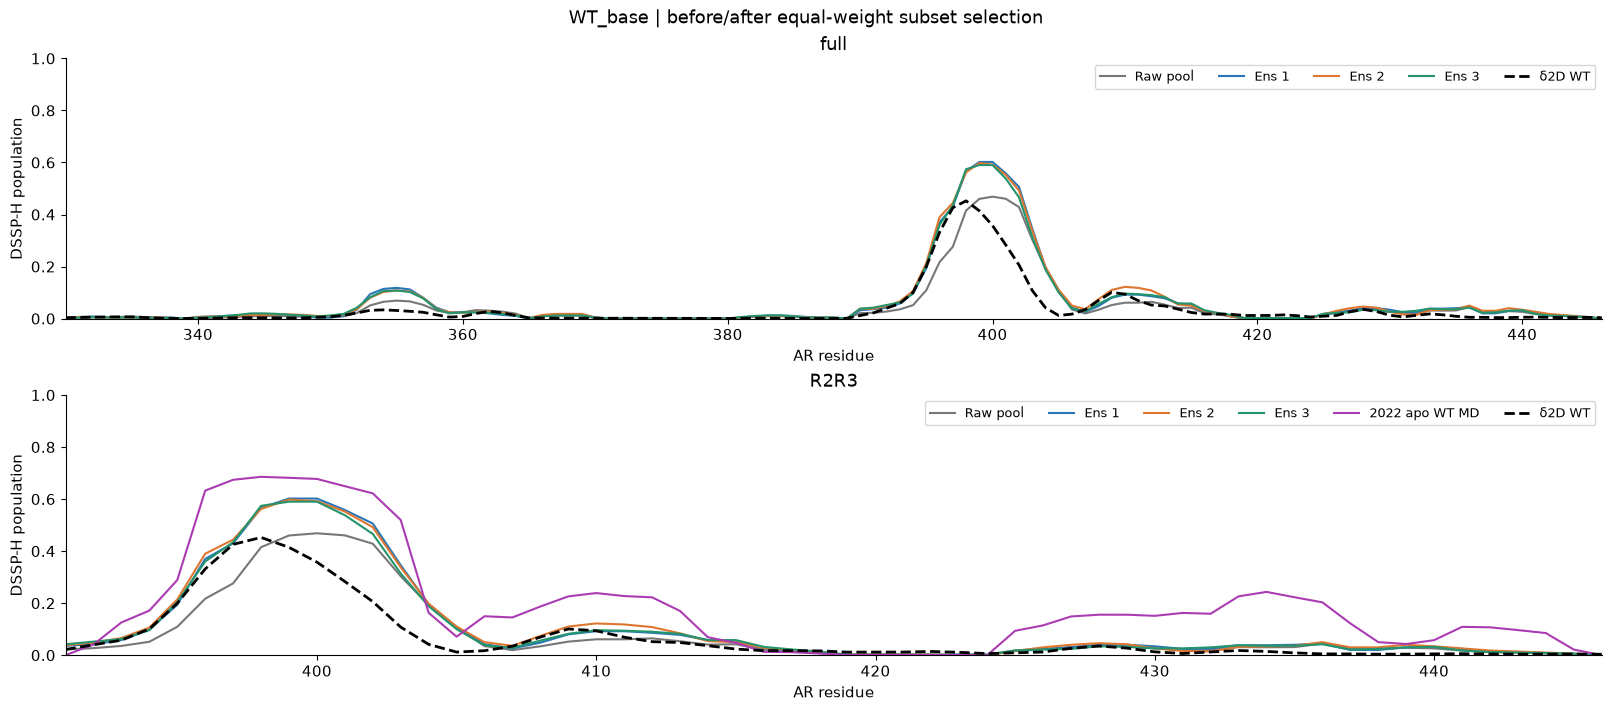

In [5]:
helicity("WT_base")

### Secondary shifts
Sequence-specific SPARTA+ random-coil shifts are subtracted from experiment and calculation. These comparisons include all available nuclei.

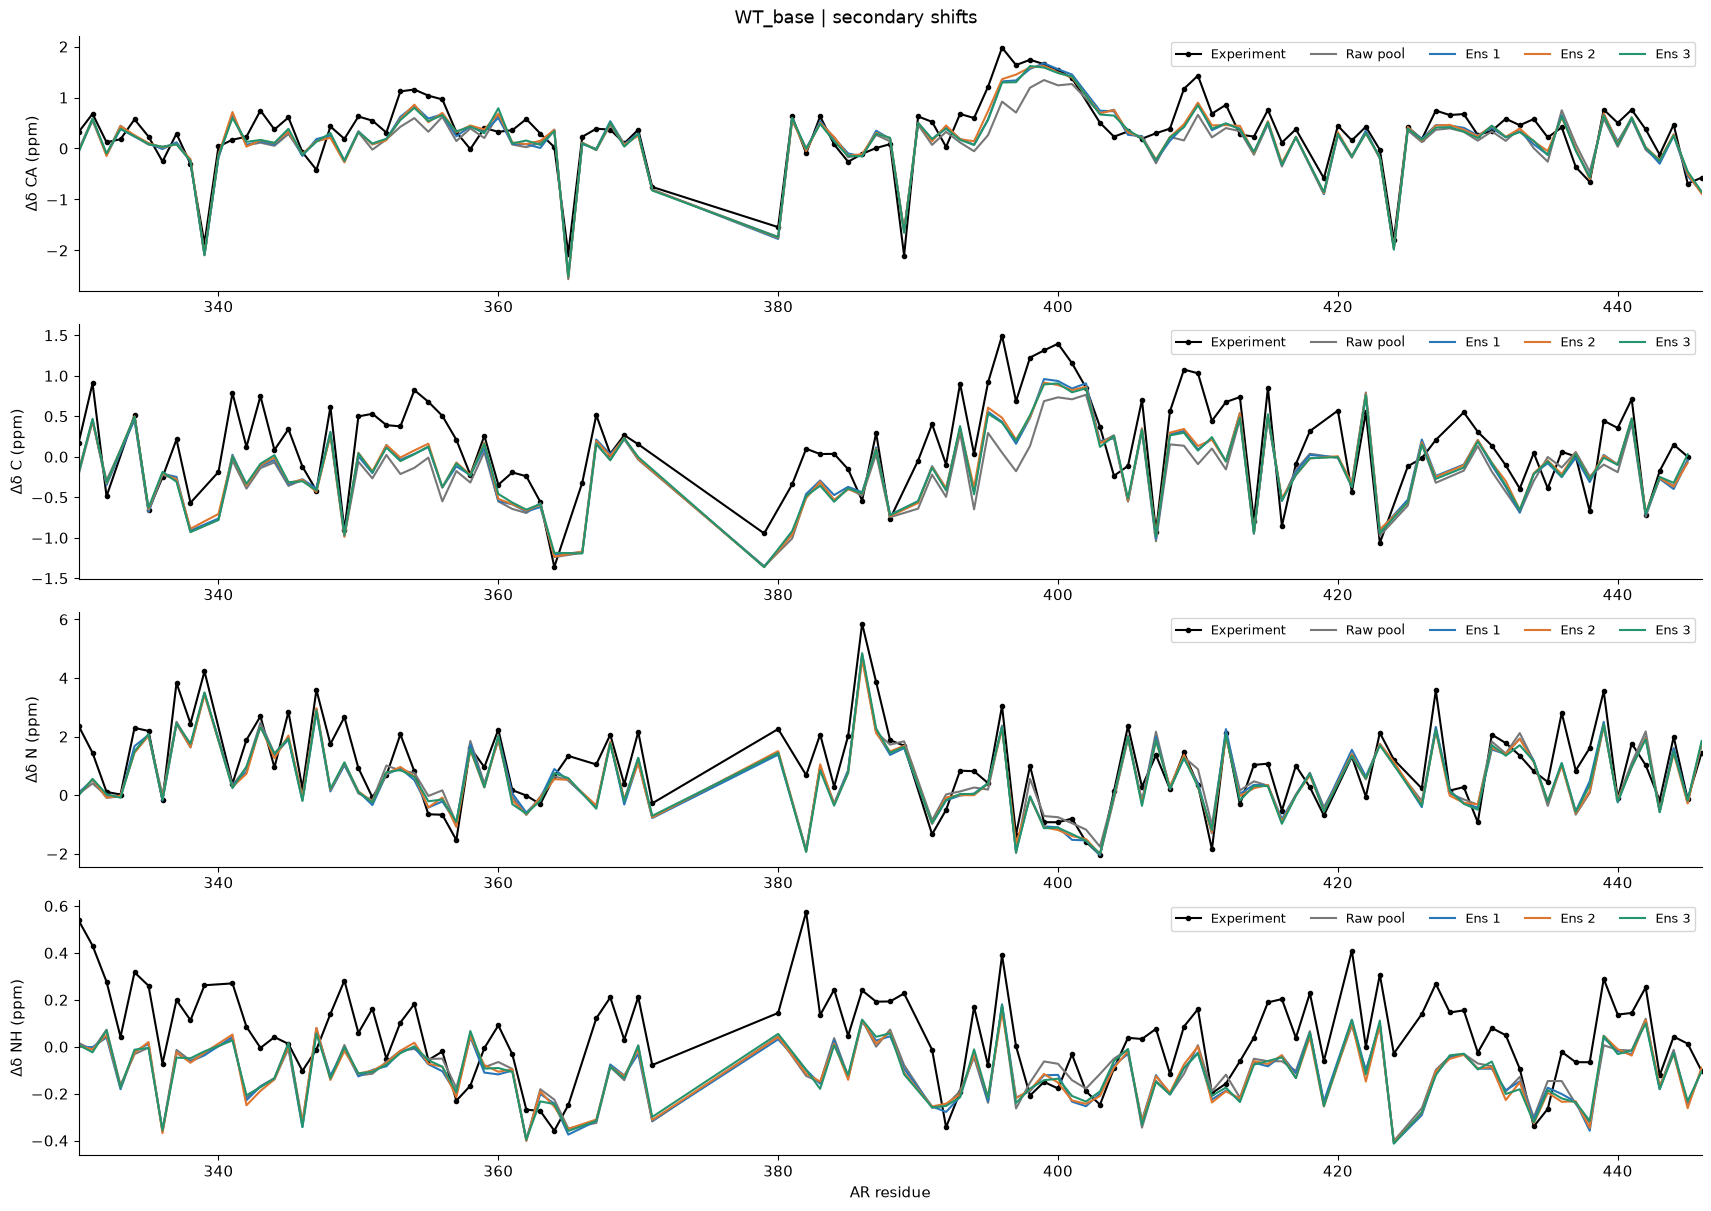

In [6]:
chemical_shifts("WT_base", secondary=True)

### CS residuals: signed and absolute
Each nucleus has separate signed and absolute bar panels. Residual = experiment − calculation; missing positions remain absent.

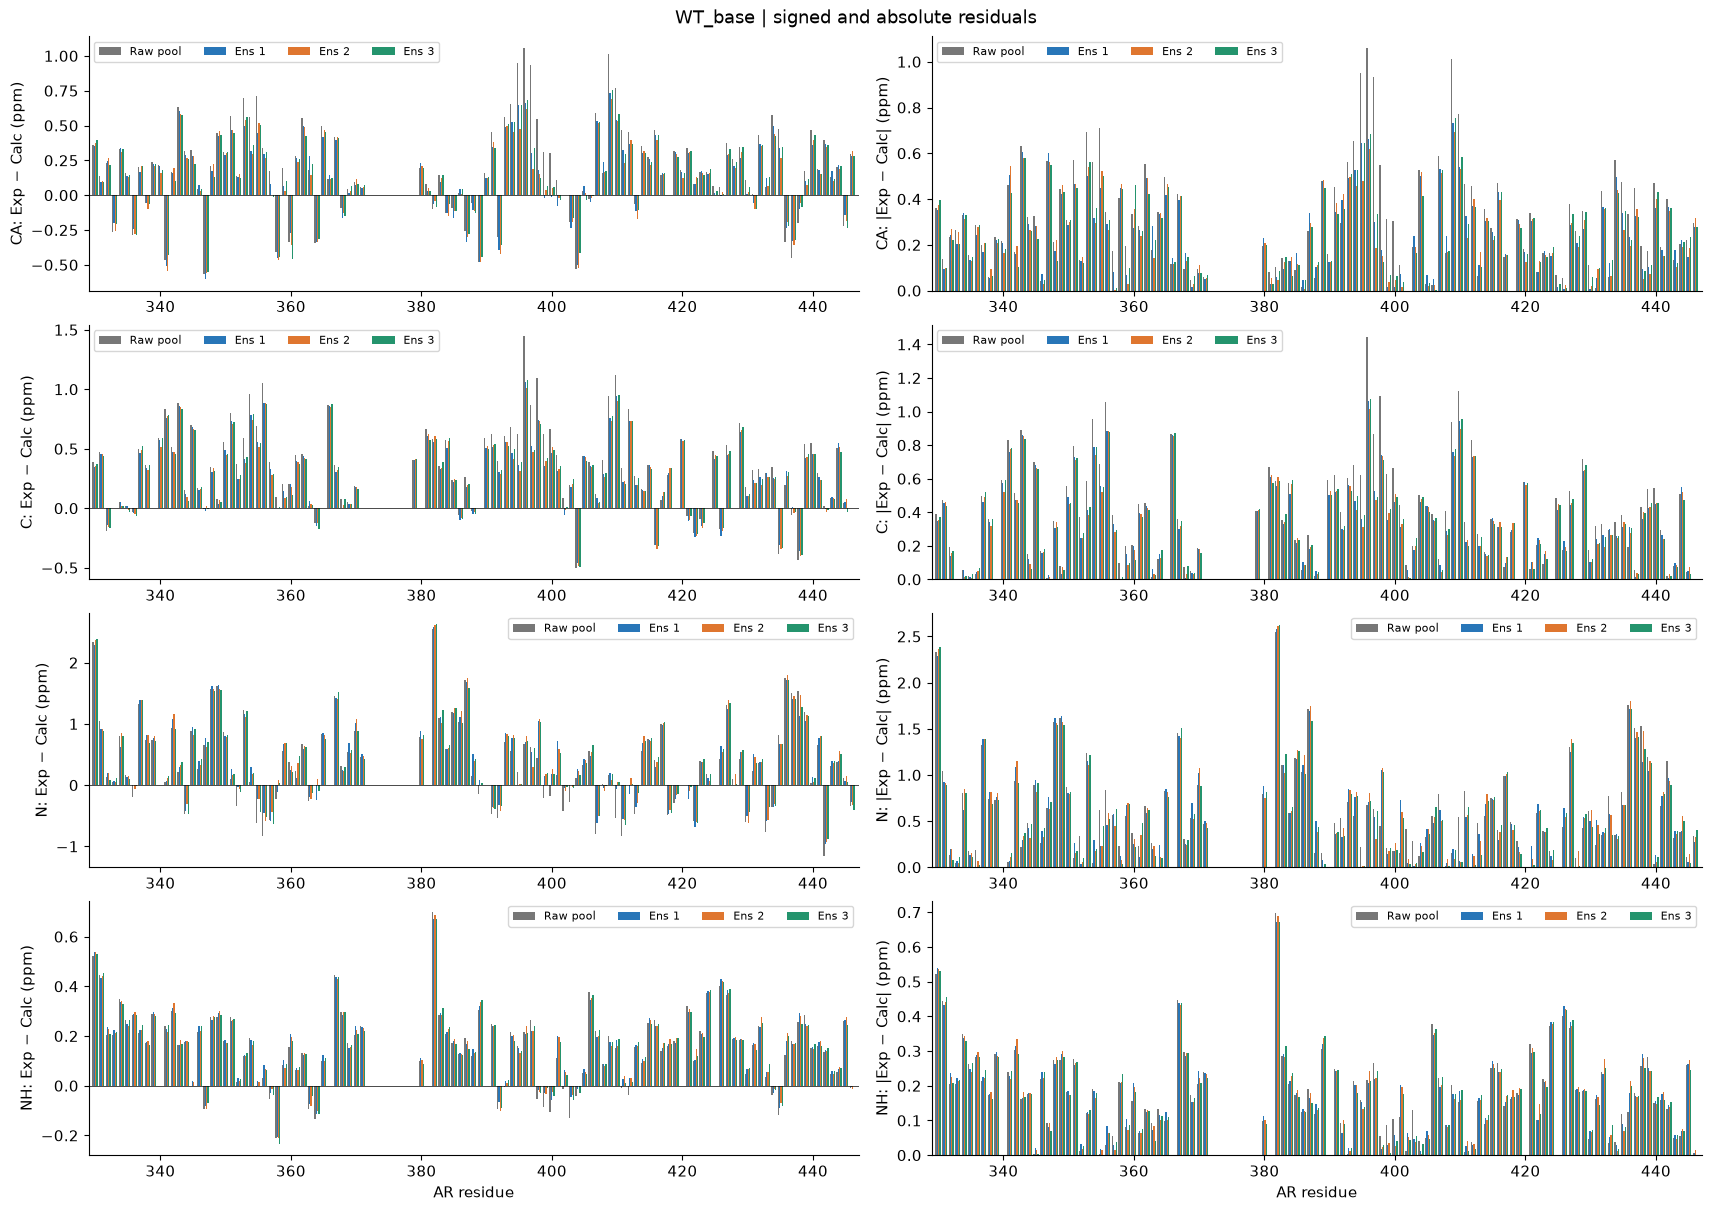

In [7]:
chemical_shifts("WT_base")

### Sα versus Rg: full chain
Original AR plotting transform: 30×30 density histogram, −0.001987×300×ln(density+10⁻⁶), Gaussian display interpolation, jet, color limits0.1–3.0. This is a sampling-density display, not a pool thermodynamic free energy.

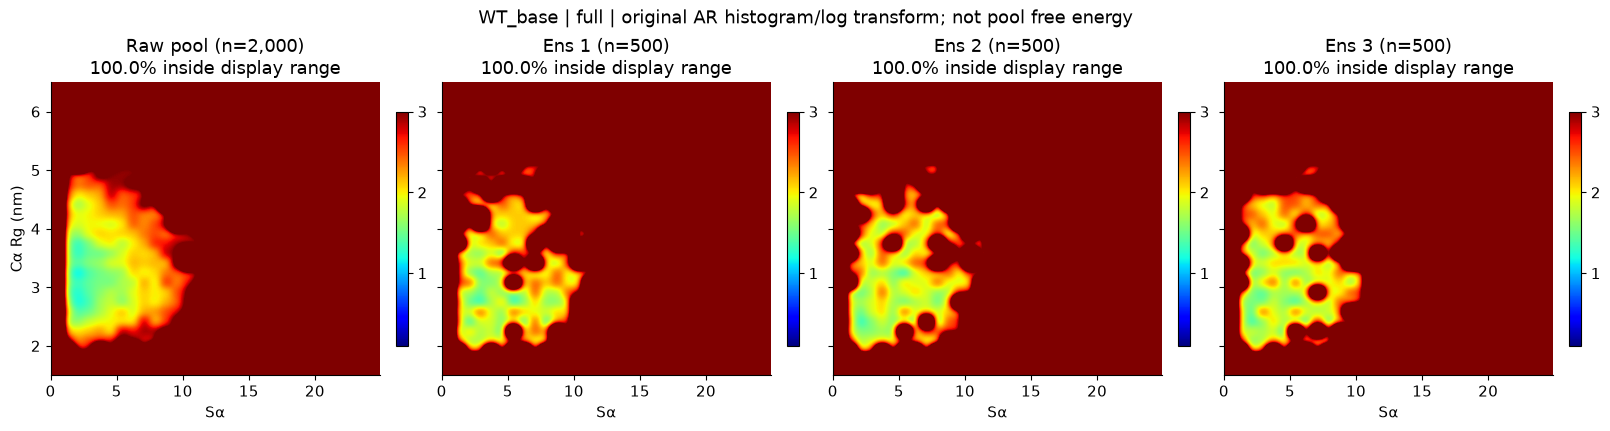

In [8]:
sa_rg("WT_base", "full")

### Sα versus Rg: matched R2–R3 plus MD
Original display range Sα0–25, Rg0.9–2.5nm. Panel titles report the retained fraction; histograms normalize within this window. Full statistics use all structures.

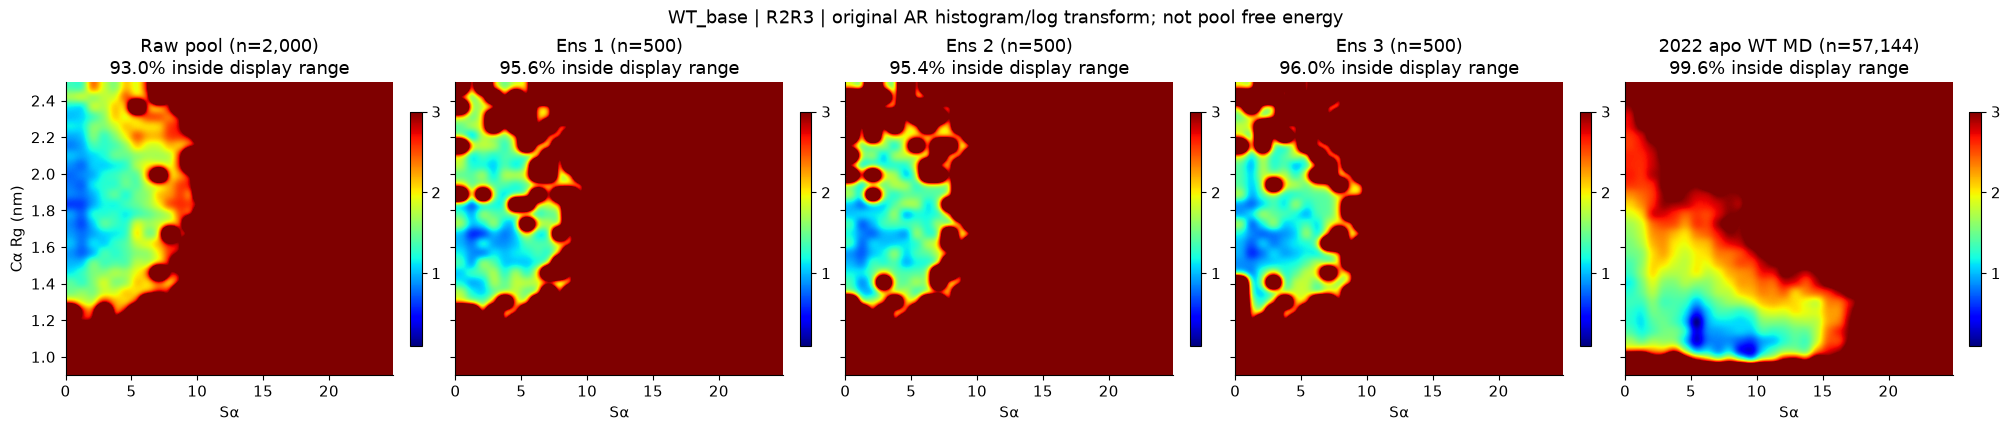

In [9]:
sa_rg("WT_base", "R2R3")

### Contact maps: full chain
Exact original closest-heavy cutoff1.2nm; diagonal zero and adjacent residues included. Shared probability scale0–1.

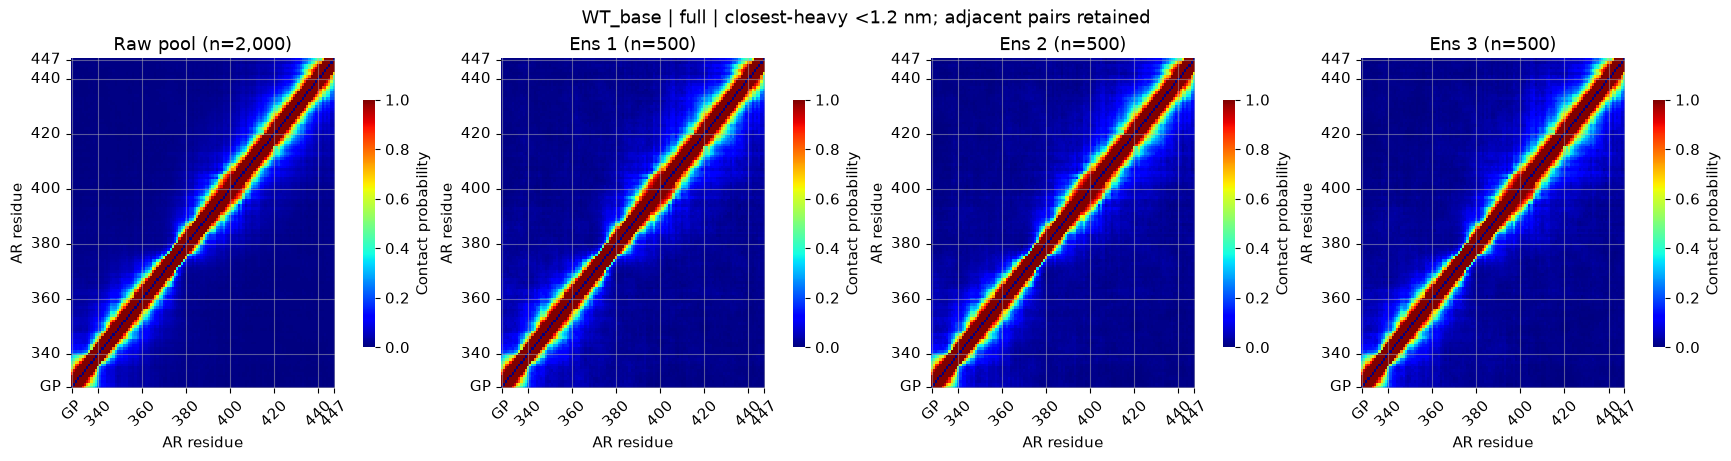

In [10]:
contacts("WT_base", "full")

### Contact maps: matched R2–R3 plus MD
Same AR391–446 segment. Current structures are cropped from full chains, whereas MD is a separately simulated capped short construct.

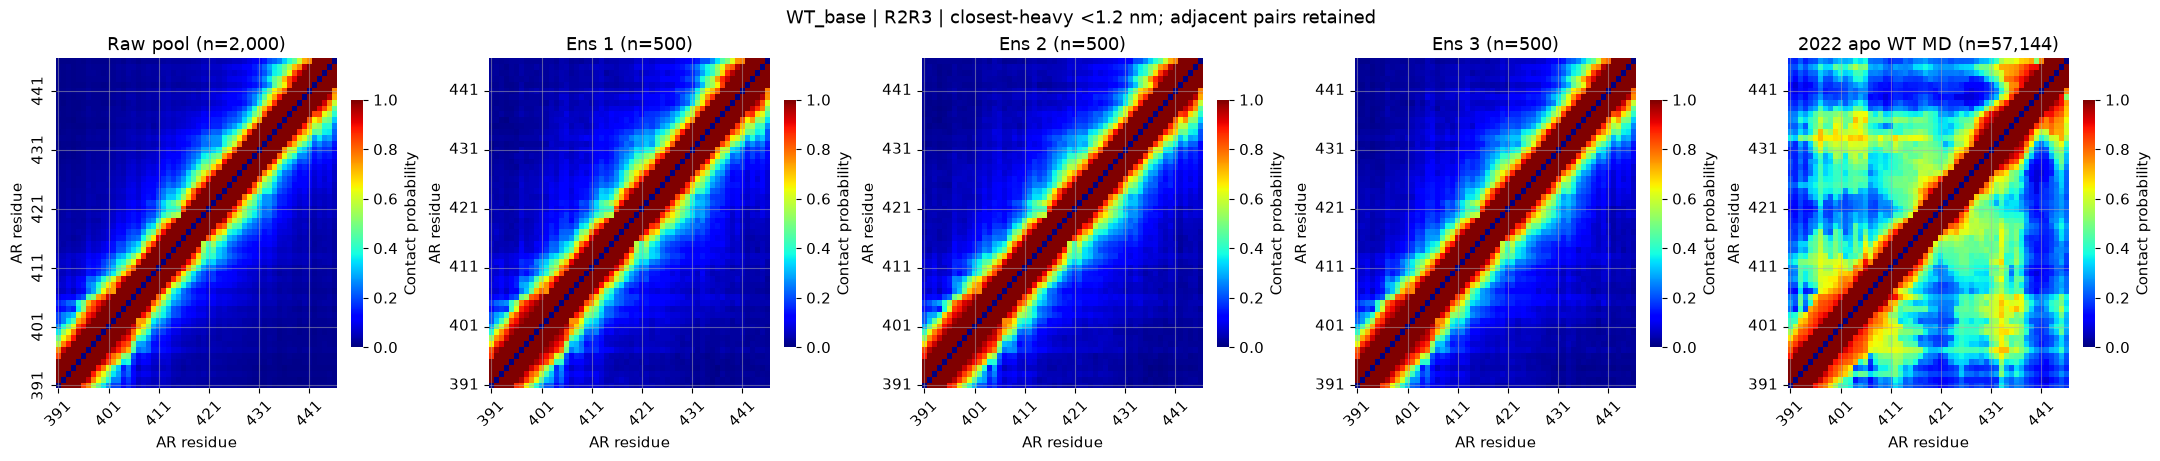

In [11]:
contacts("WT_base", "R2R3")

### Sα and helix-length histograms: full chain
Helix lengths are maximal contiguous DSSP-H runs. Middle panel: expected number of runs of each length per conformer, so helices/conformer can sum above one. Right panel includes longest length0 for conformers with no H run.

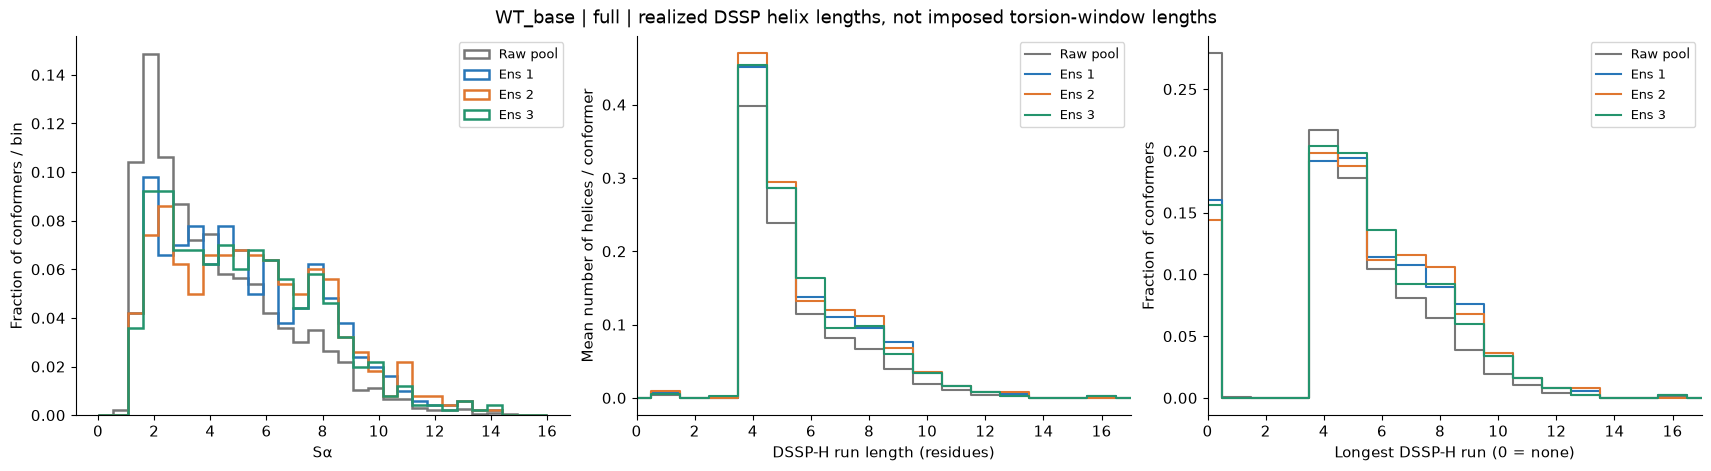

In [12]:
distributions("WT_base", "full")

### Sα and helix-length histograms: R2–R3 plus MD
Runs are clipped at segment boundaries. The Sα histogram is a fraction of conformers per common bin; all Sα values are included.

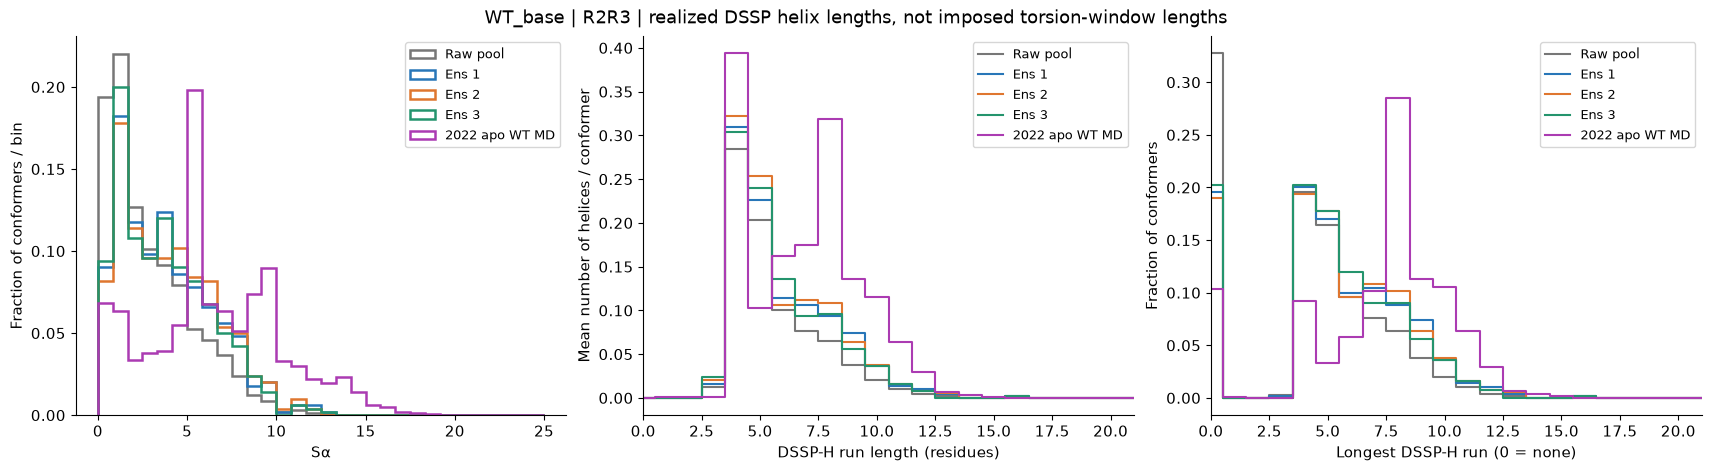

In [13]:
distributions("WT_base", "R2R3")

## WT expanded
Raw candidate pool versus all three 500-member selections. Ens1/2/3 correspond to optimizer seeds20260929/20261029/20261129. The MD comparator is always apo WT R2–R3, including in AA panels; it is not an AA simulation.

### SAXS before and after fitting
Each curve uses its own optimized nonnegative intensity scale; background is fixed to zero. Low-q slope annotations are diagnostic, not a separate restraint.

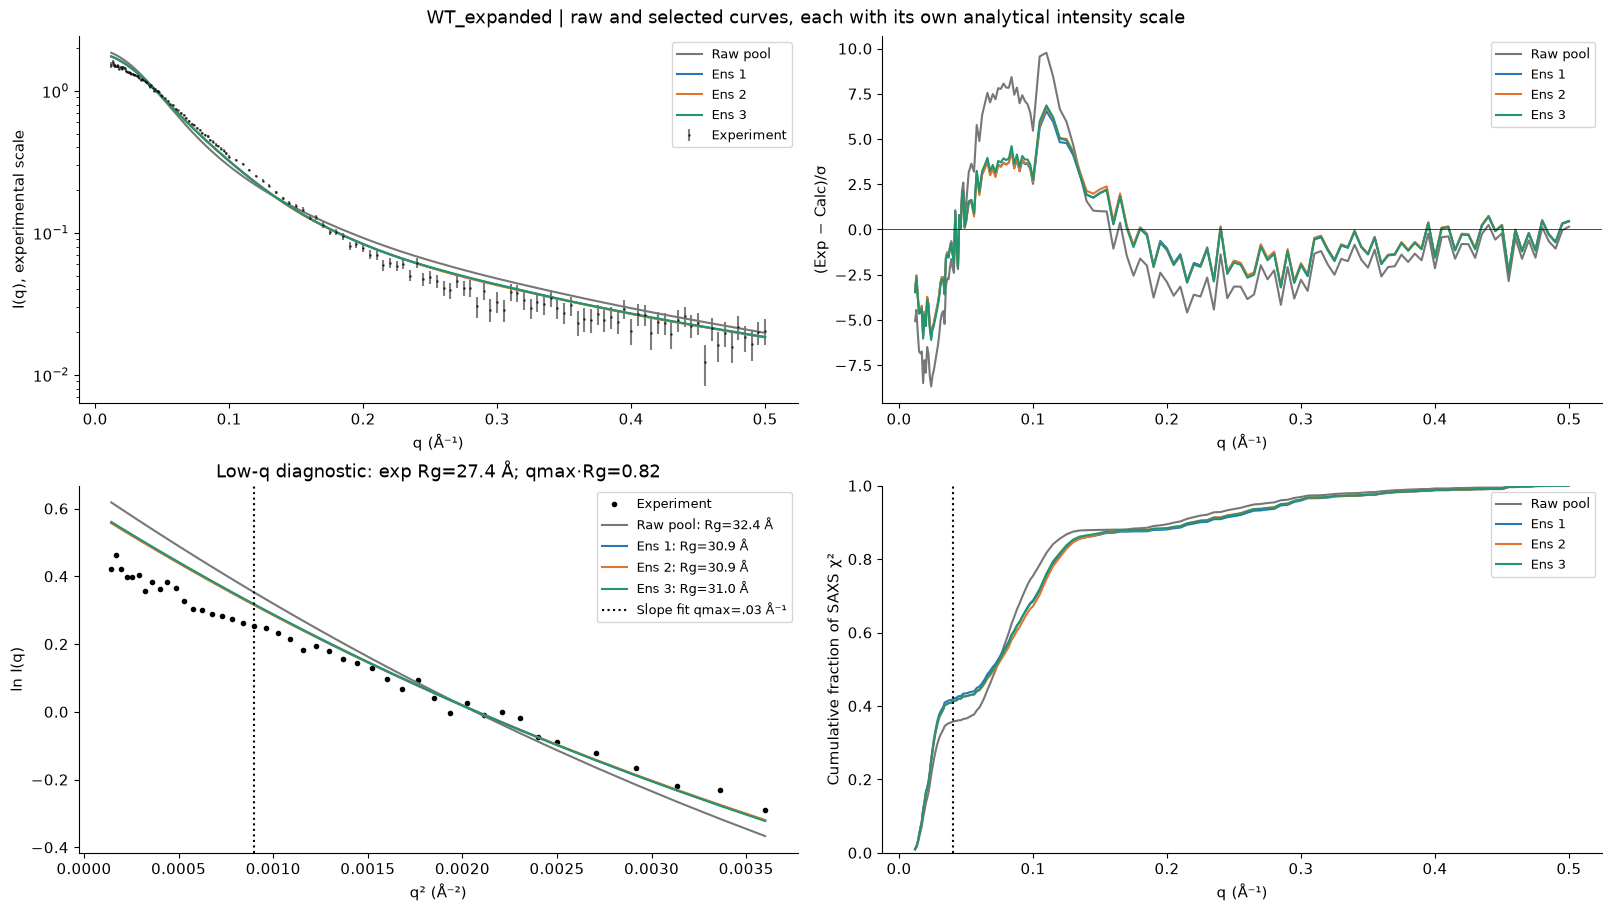

In [14]:
saxs("WT_expanded")

### Helix before and after selection
DSSP H and δ2D are distinct observables. Display excludes the added GP and terminal P447, as in earlier profiles. MD DSSP is calculated on the 56-residue core with caps excluded.

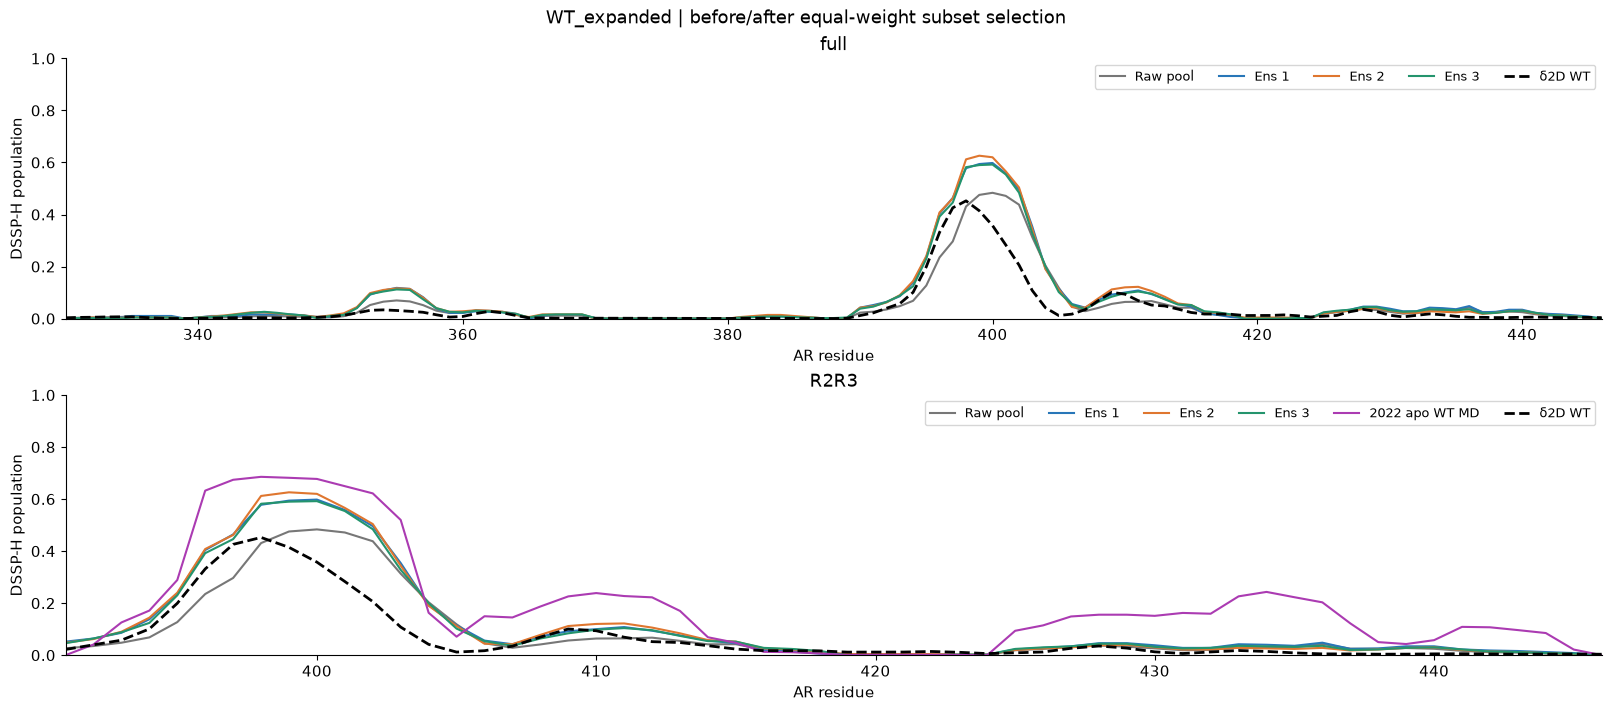

In [15]:
helicity("WT_expanded")

### Secondary shifts
Sequence-specific SPARTA+ random-coil shifts are subtracted from experiment and calculation. These comparisons include all available nuclei.

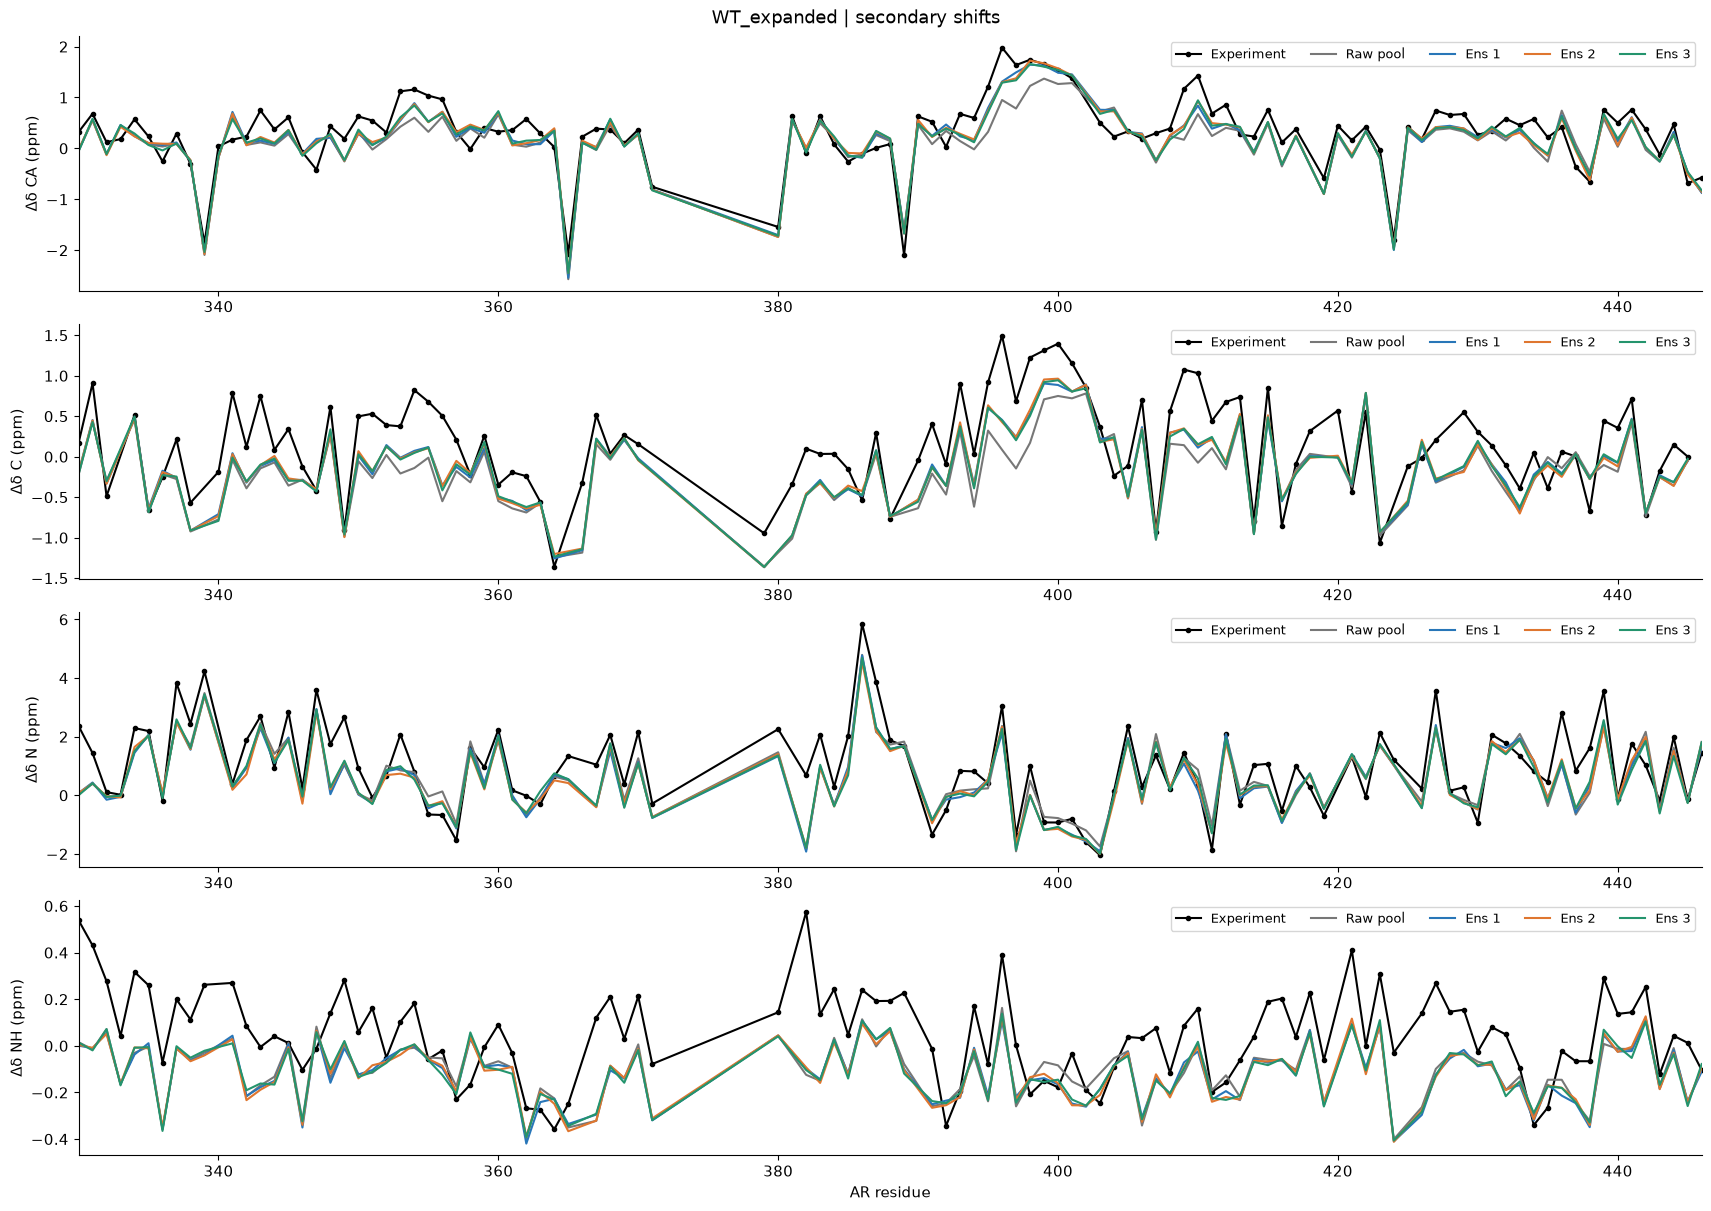

In [16]:
chemical_shifts("WT_expanded", secondary=True)

### CS residuals: signed and absolute
Each nucleus has separate signed and absolute bar panels. Residual = experiment − calculation; missing positions remain absent.

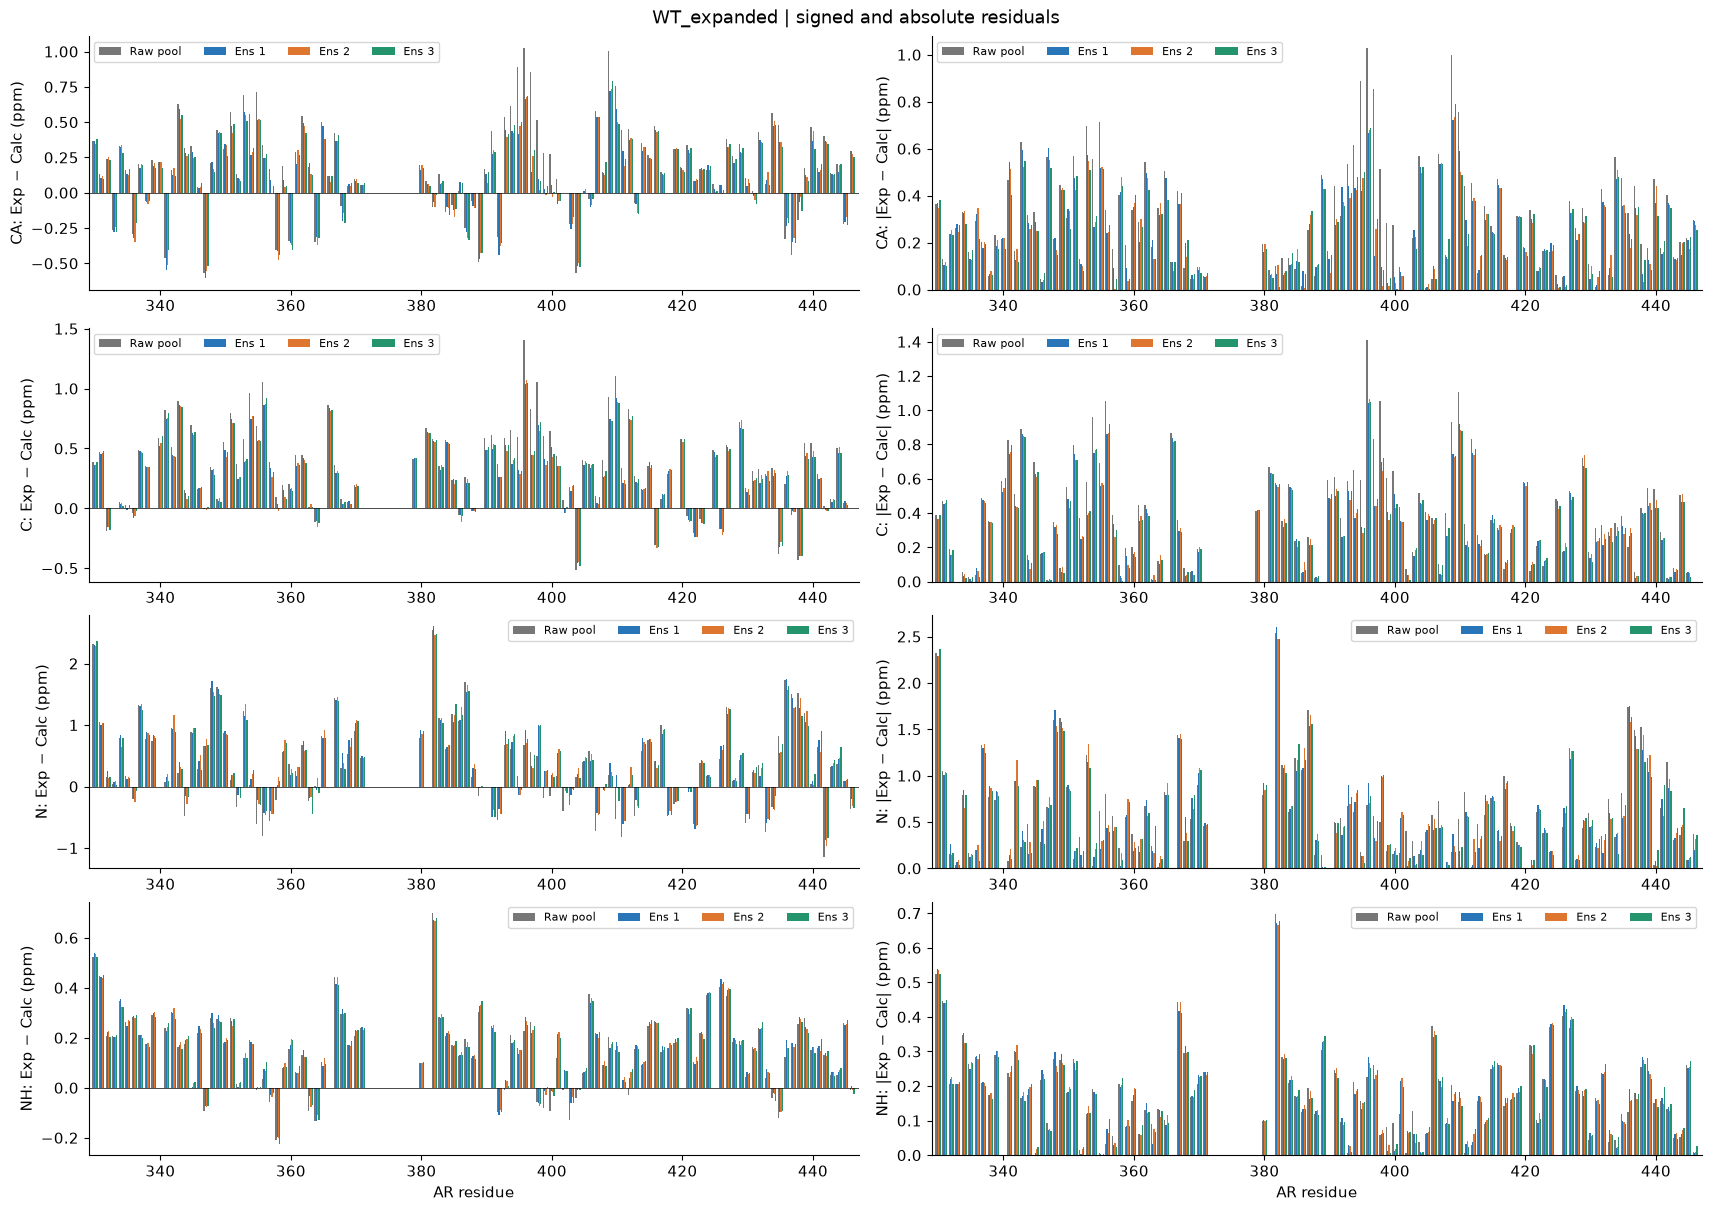

In [17]:
chemical_shifts("WT_expanded")

### Sα versus Rg: full chain
Original AR plotting transform: 30×30 density histogram, −0.001987×300×ln(density+10⁻⁶), Gaussian display interpolation, jet, color limits0.1–3.0. This is a sampling-density display, not a pool thermodynamic free energy.

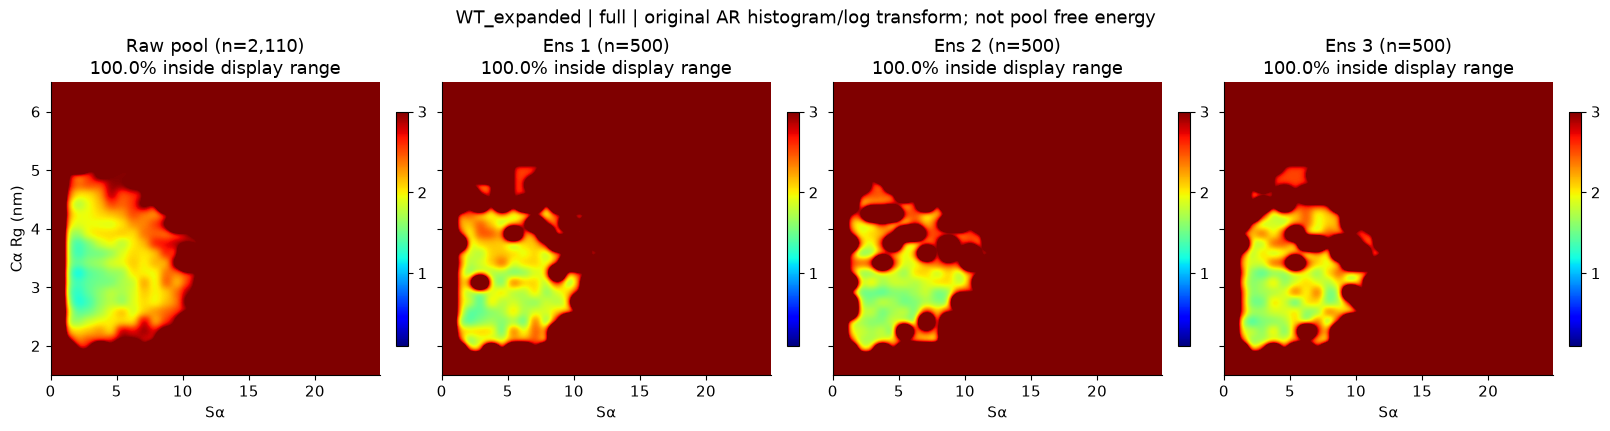

In [18]:
sa_rg("WT_expanded", "full")

### Sα versus Rg: matched R2–R3 plus MD
Original display range Sα0–25, Rg0.9–2.5nm. Panel titles report the retained fraction; histograms normalize within this window. Full statistics use all structures.

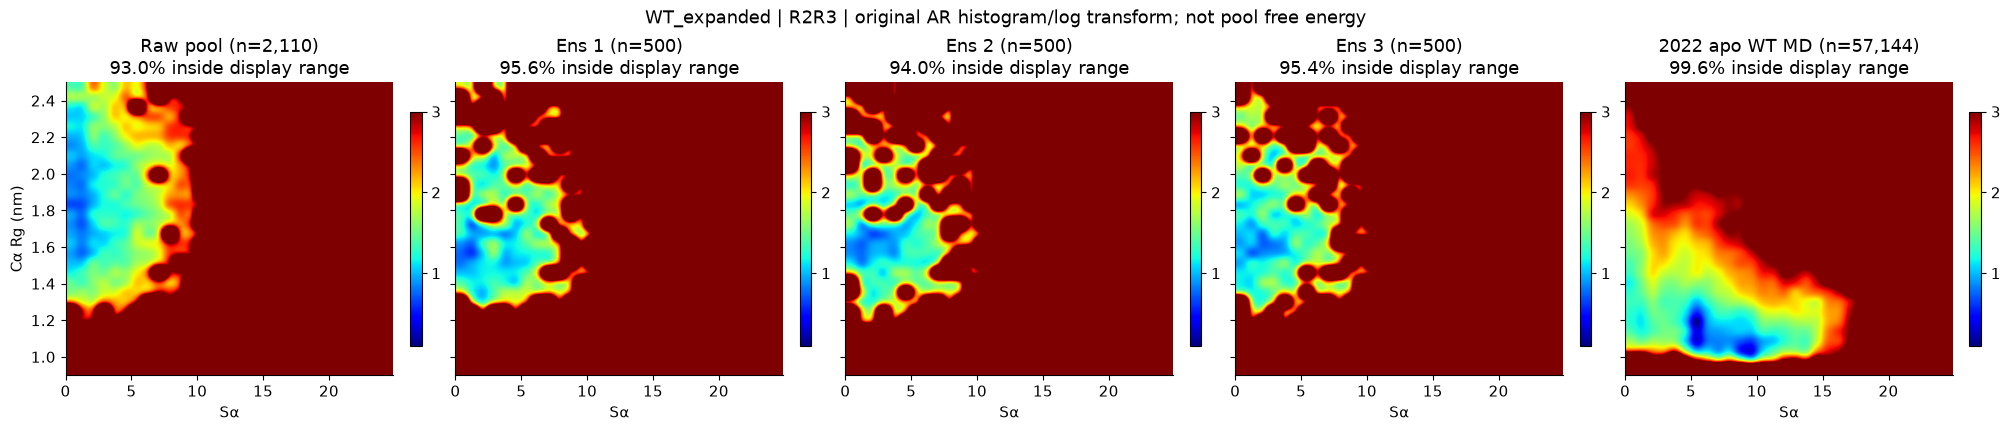

In [19]:
sa_rg("WT_expanded", "R2R3")

### Contact maps: full chain
Exact original closest-heavy cutoff1.2nm; diagonal zero and adjacent residues included. Shared probability scale0–1.

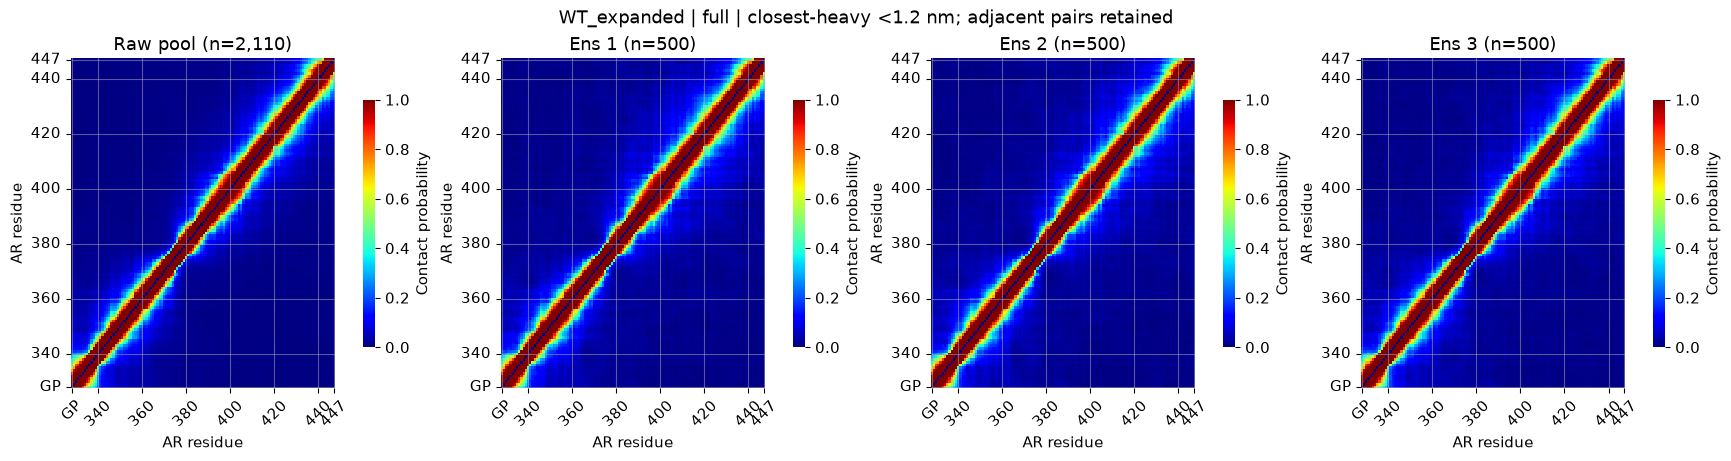

In [20]:
contacts("WT_expanded", "full")

### Contact maps: matched R2–R3 plus MD
Same AR391–446 segment. Current structures are cropped from full chains, whereas MD is a separately simulated capped short construct.

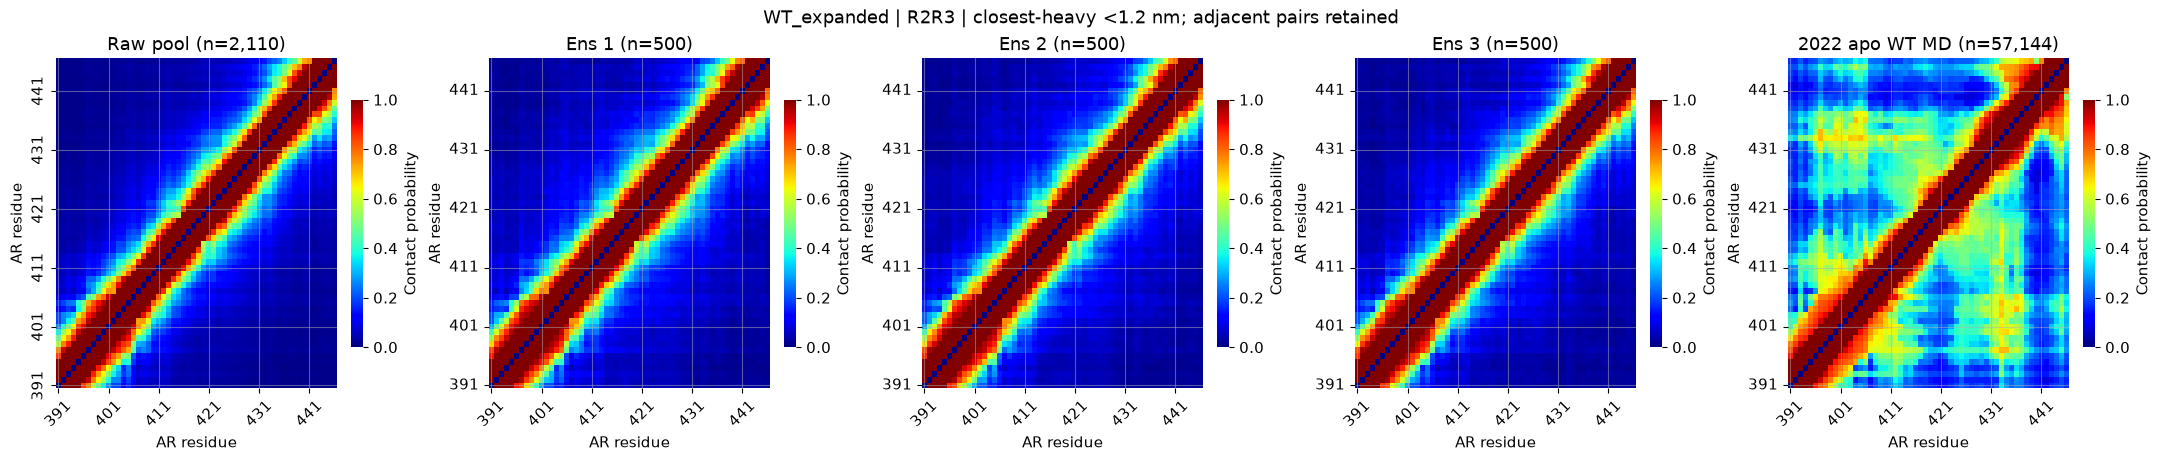

In [21]:
contacts("WT_expanded", "R2R3")

### Sα and helix-length histograms: full chain
Helix lengths are maximal contiguous DSSP-H runs. Middle panel: expected number of runs of each length per conformer, so helices/conformer can sum above one. Right panel includes longest length0 for conformers with no H run.

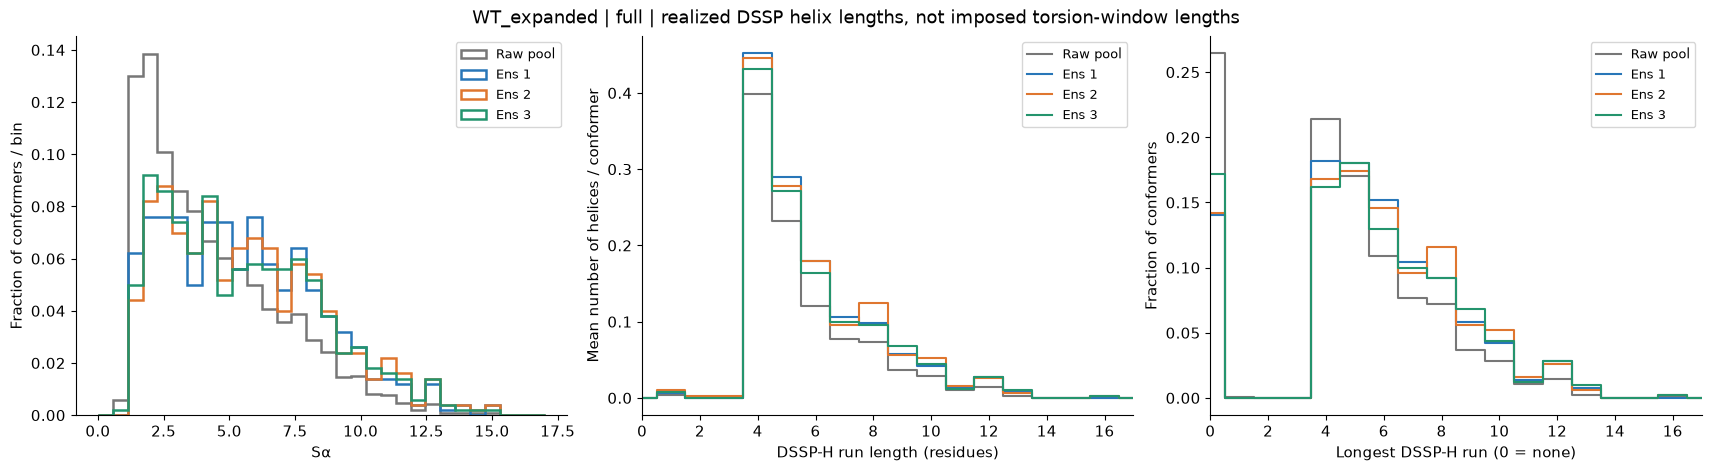

In [22]:
distributions("WT_expanded", "full")

### Sα and helix-length histograms: R2–R3 plus MD
Runs are clipped at segment boundaries. The Sα histogram is a fraction of conformers per common bin; all Sα values are included.

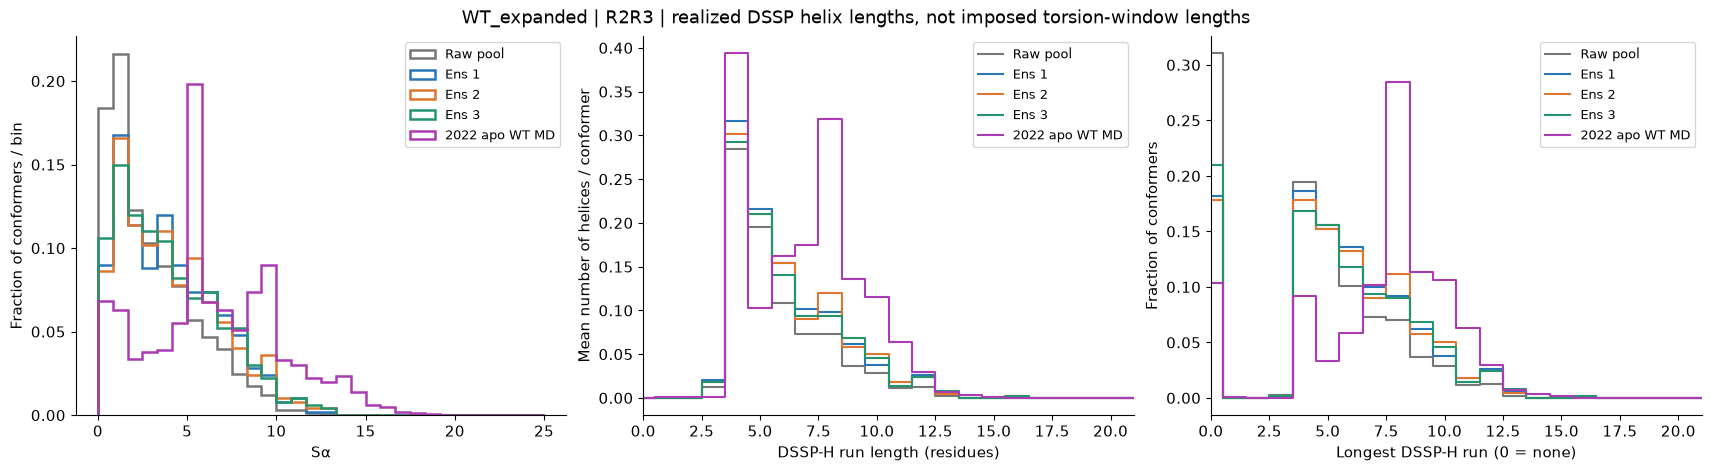

In [23]:
distributions("WT_expanded", "R2R3")

## AA base
Raw candidate pool versus all three 500-member selections. Ens1/2/3 correspond to optimizer seeds20260929/20261029/20261129. The MD comparator is always apo WT R2–R3, including in AA panels; it is not an AA simulation.

### SAXS before and after fitting
Each curve uses its own optimized nonnegative intensity scale; background is fixed to zero. Low-q slope annotations are diagnostic, not a separate restraint.

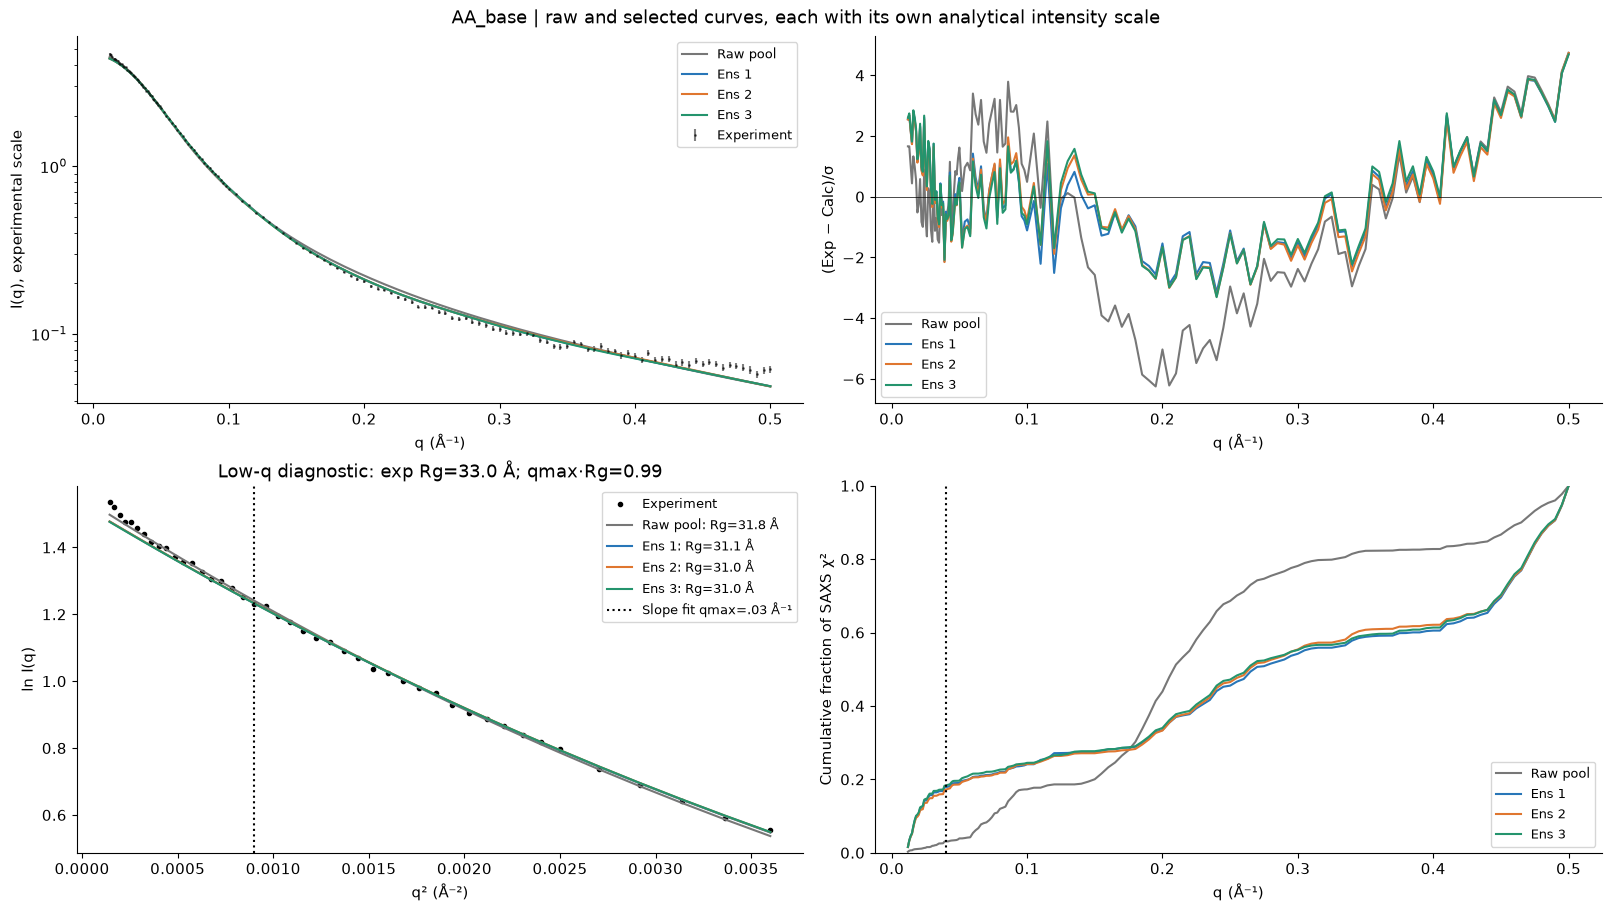

In [24]:
saxs("AA_base")

### Helix before and after selection
DSSP H and δ2D are distinct observables. Display excludes the added GP and terminal P447, as in earlier profiles. MD DSSP is calculated on the 56-residue core with caps excluded.

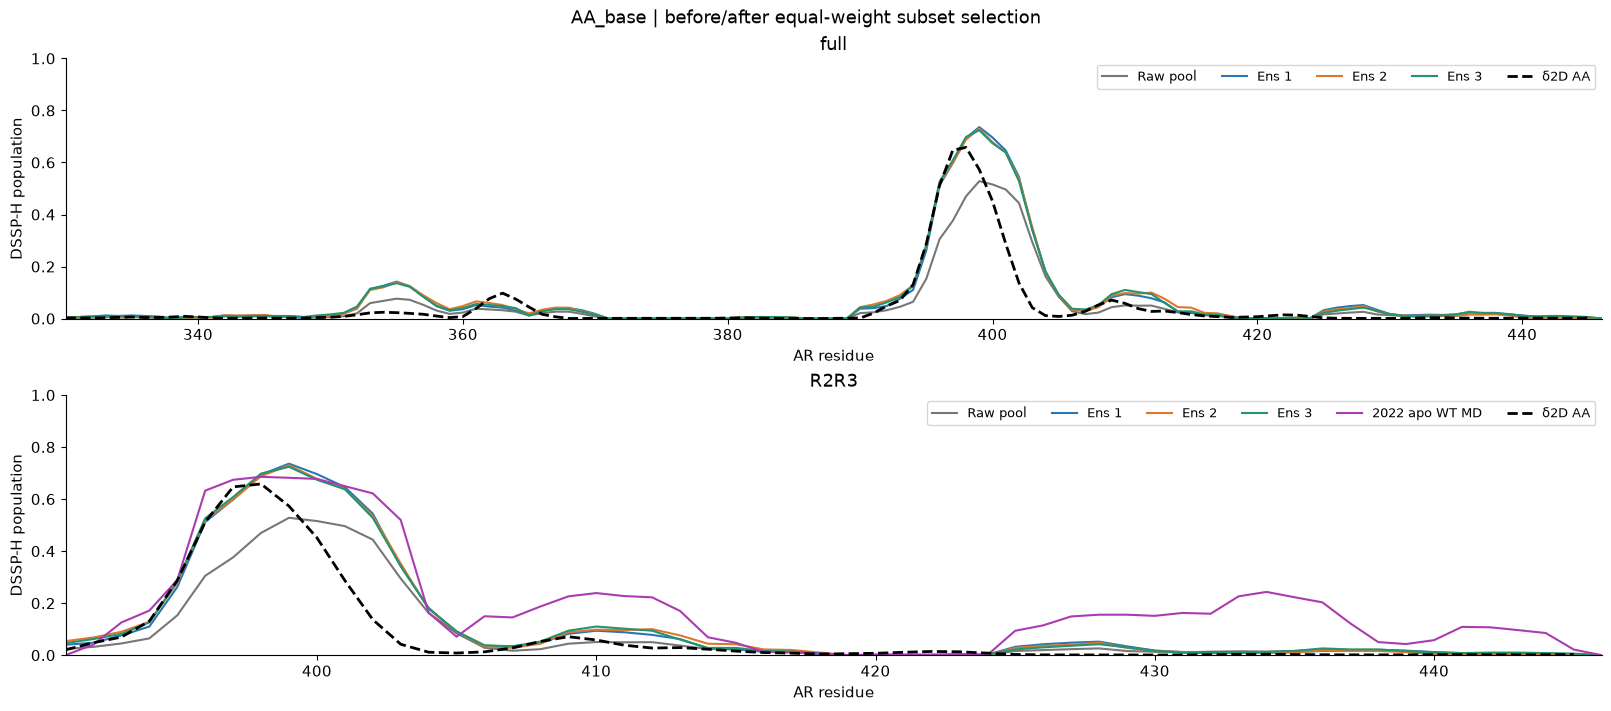

In [25]:
helicity("AA_base")

### Secondary shifts
Sequence-specific SPARTA+ random-coil shifts are subtracted from experiment and calculation. These comparisons include all available nuclei.

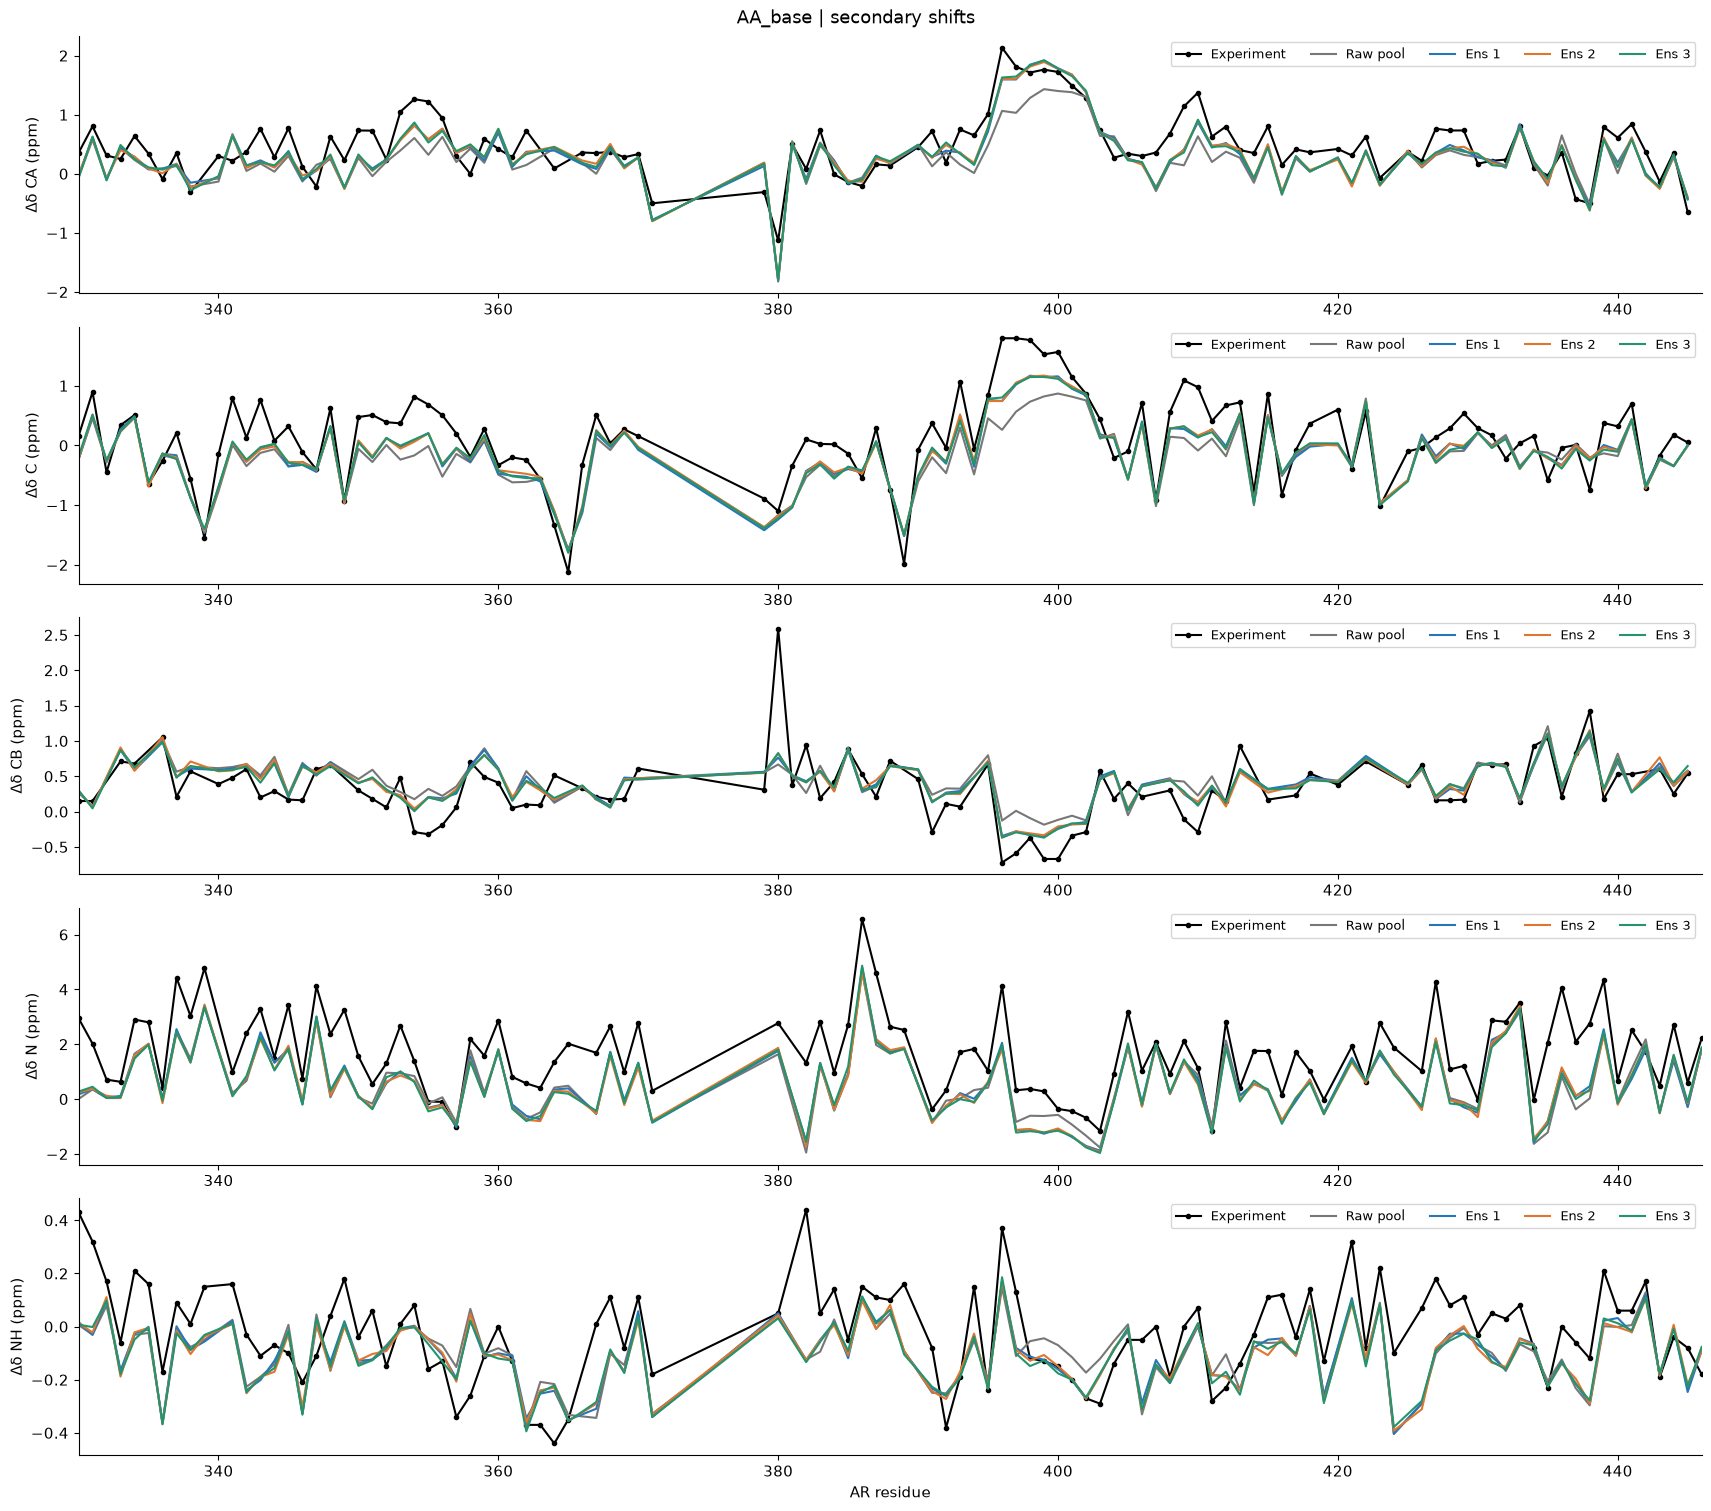

In [26]:
chemical_shifts("AA_base", secondary=True)

### CS residuals: signed and absolute
Each nucleus has separate signed and absolute bar panels. Residual = experiment − calculation; missing positions remain absent.

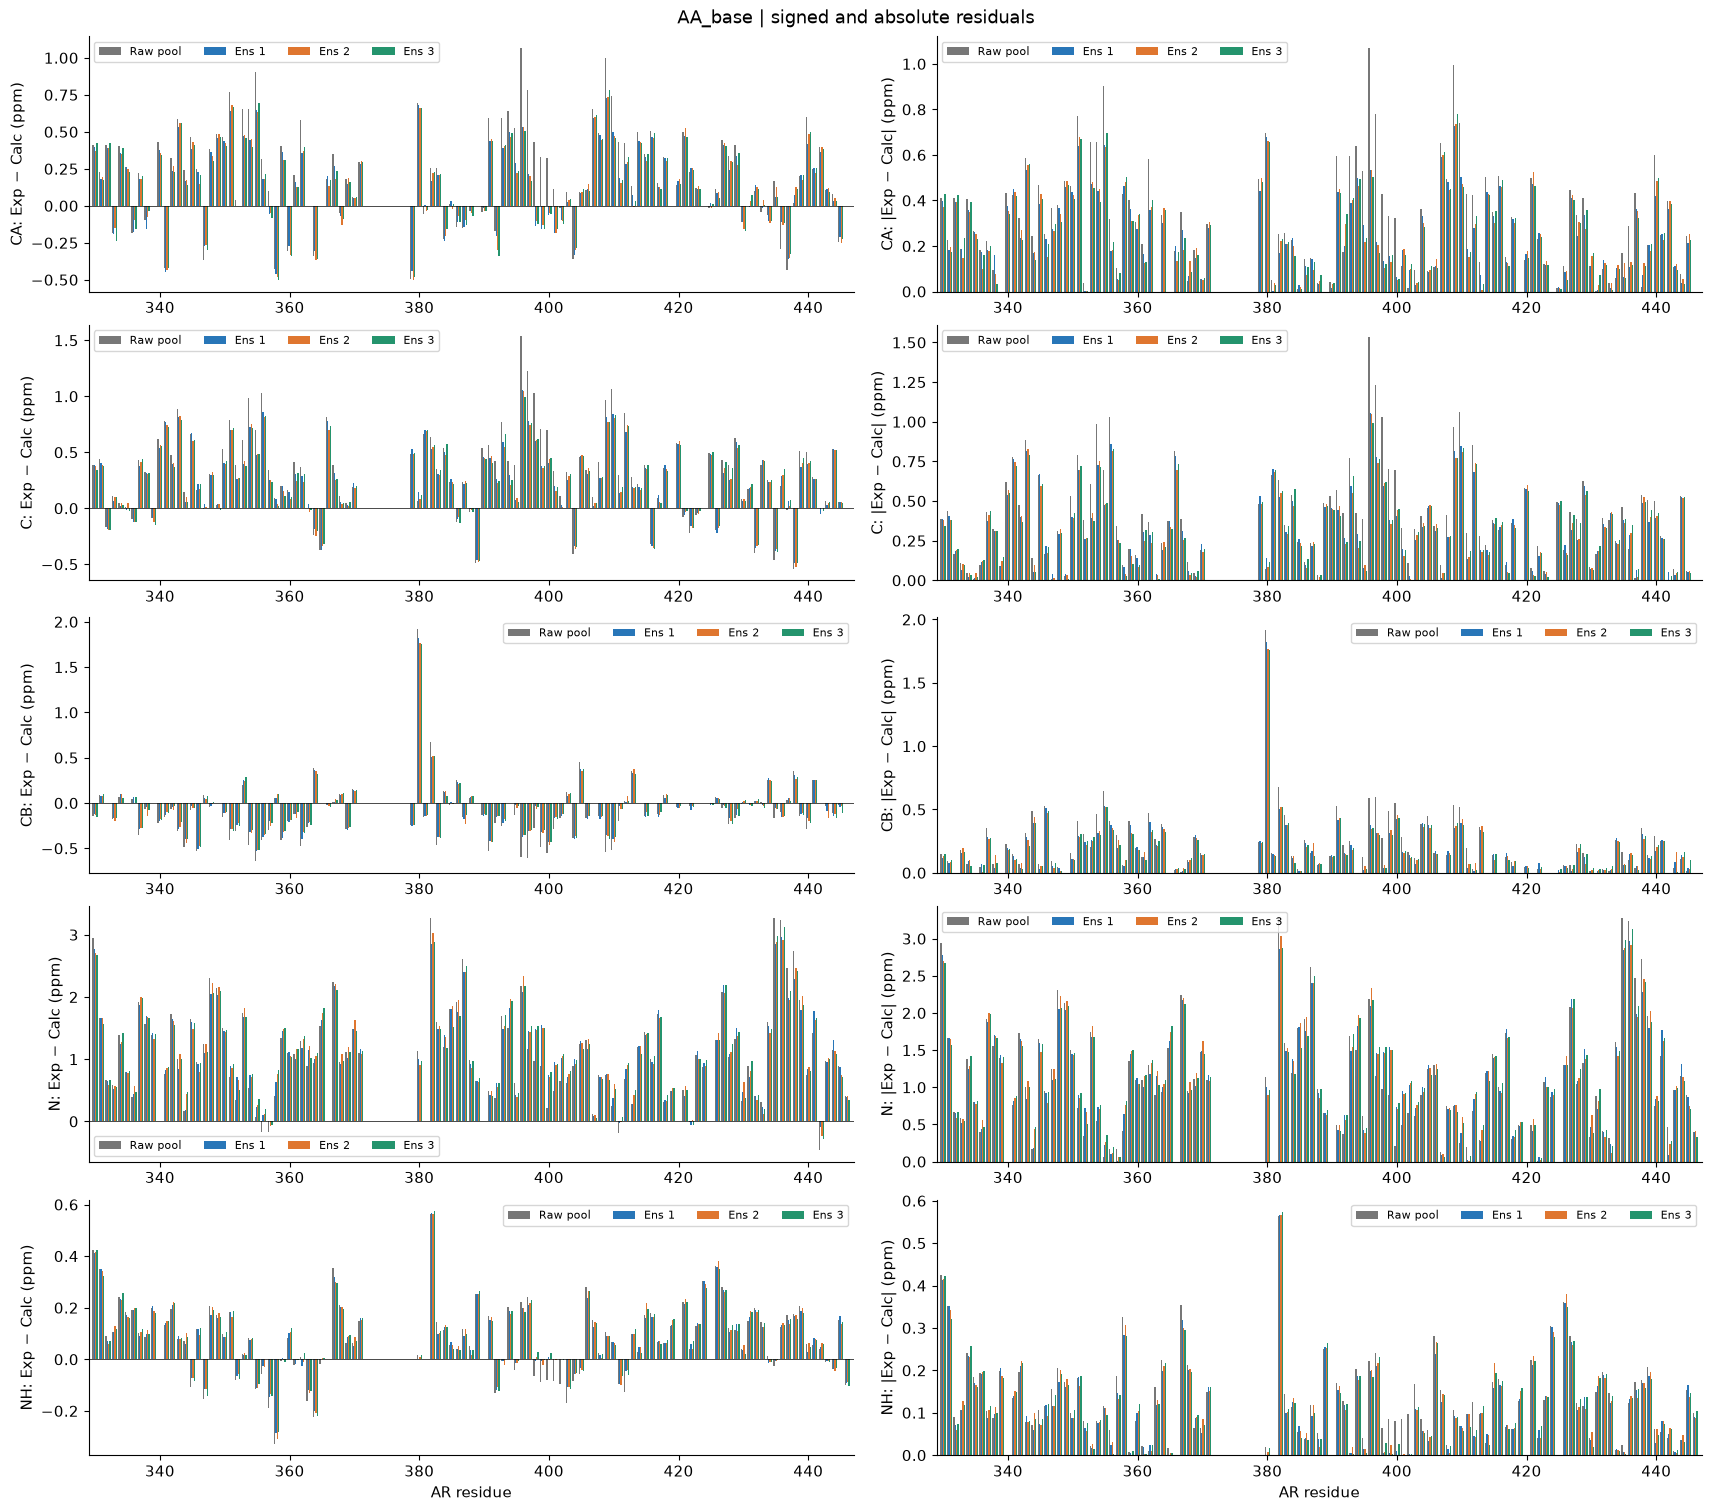

In [27]:
chemical_shifts("AA_base")

### Sα versus Rg: full chain
Original AR plotting transform: 30×30 density histogram, −0.001987×300×ln(density+10⁻⁶), Gaussian display interpolation, jet, color limits0.1–3.0. This is a sampling-density display, not a pool thermodynamic free energy.

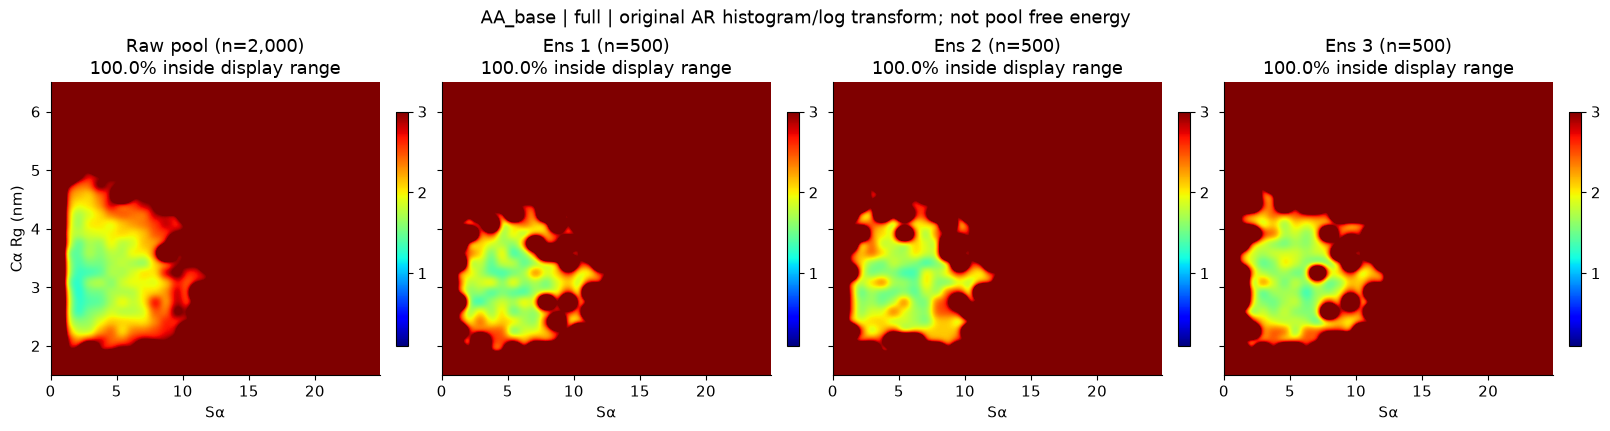

In [28]:
sa_rg("AA_base", "full")

### Sα versus Rg: matched R2–R3 plus MD
Original display range Sα0–25, Rg0.9–2.5nm. Panel titles report the retained fraction; histograms normalize within this window. Full statistics use all structures.

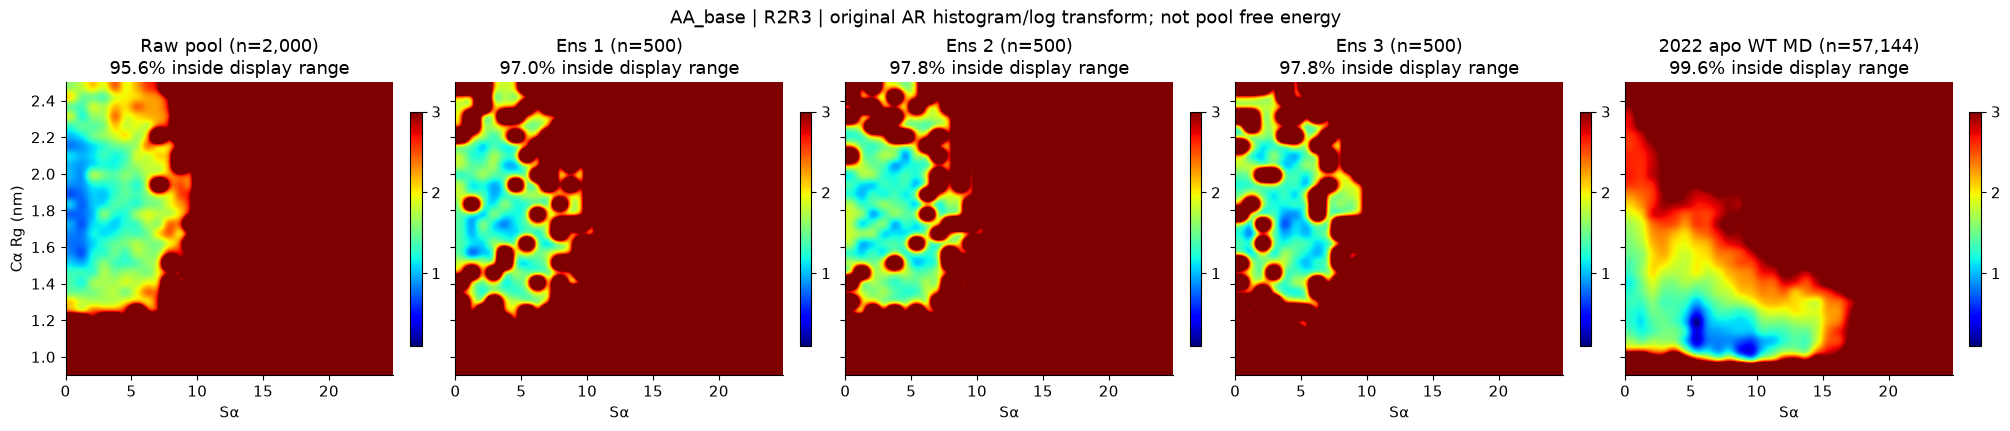

In [29]:
sa_rg("AA_base", "R2R3")

### Contact maps: full chain
Exact original closest-heavy cutoff1.2nm; diagonal zero and adjacent residues included. Shared probability scale0–1.

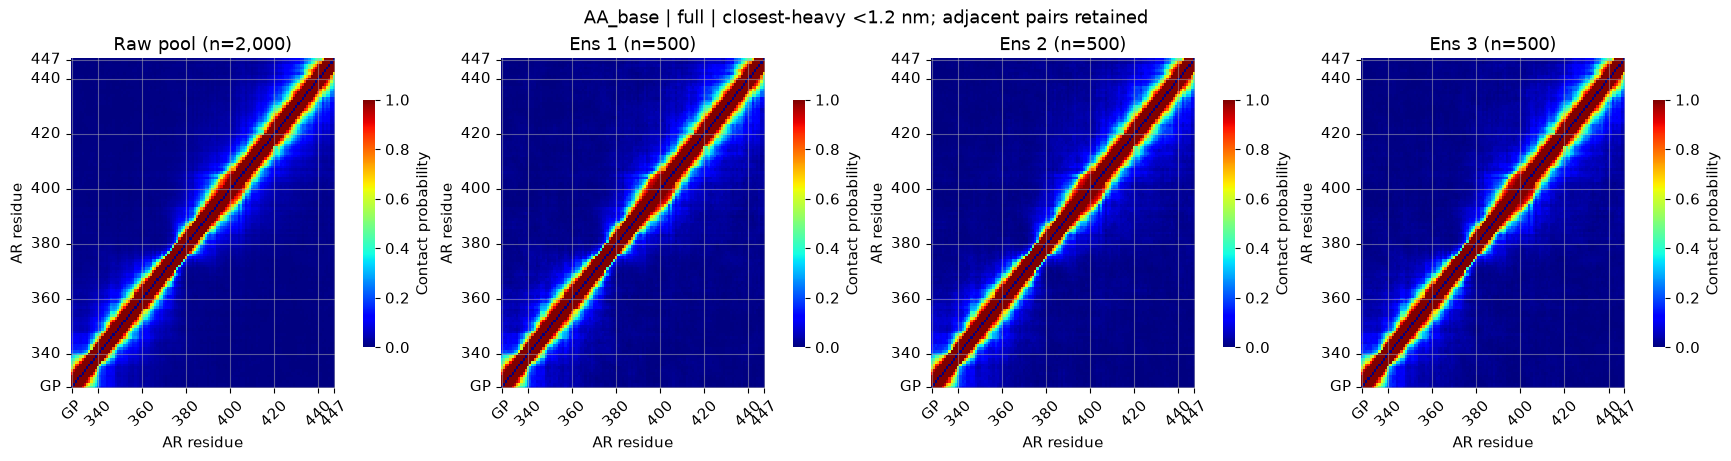

In [30]:
contacts("AA_base", "full")

### Contact maps: matched R2–R3 plus MD
Same AR391–446 segment. Current structures are cropped from full chains, whereas MD is a separately simulated capped short construct.

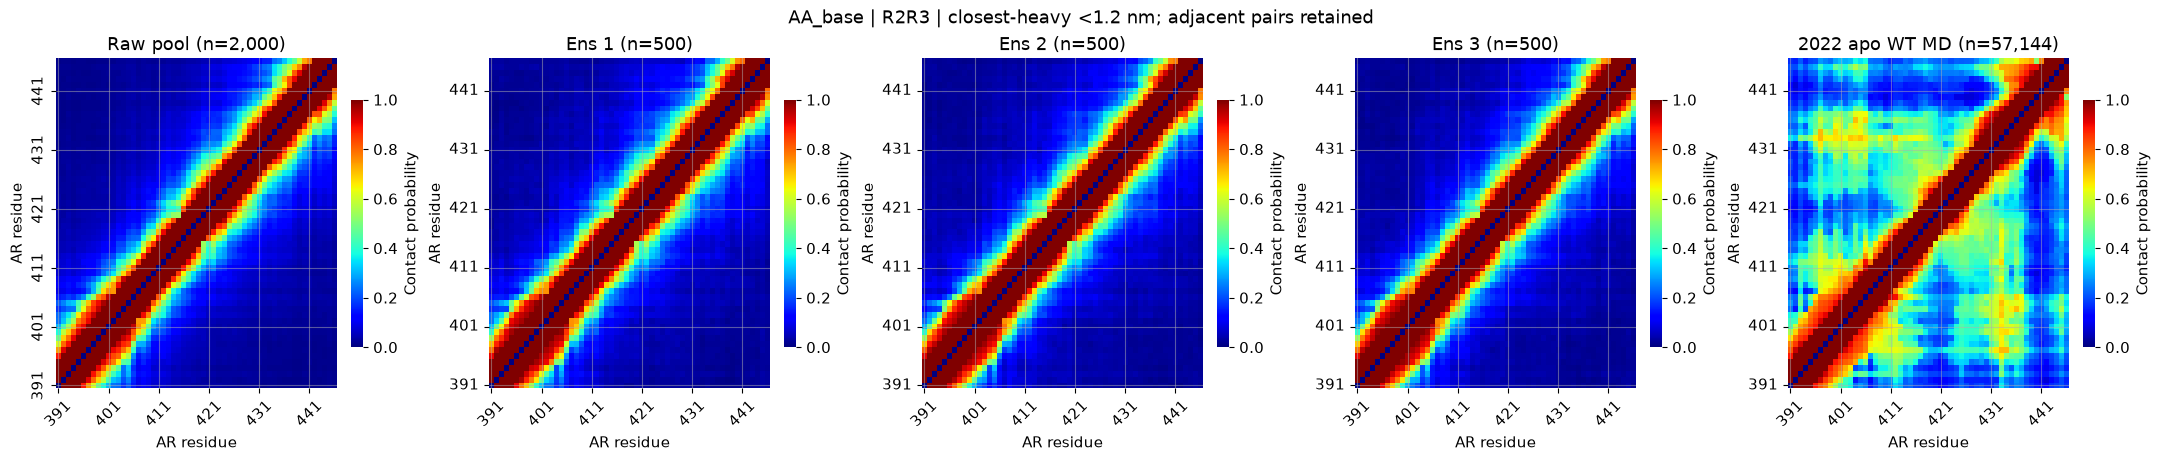

In [31]:
contacts("AA_base", "R2R3")

### Sα and helix-length histograms: full chain
Helix lengths are maximal contiguous DSSP-H runs. Middle panel: expected number of runs of each length per conformer, so helices/conformer can sum above one. Right panel includes longest length0 for conformers with no H run.

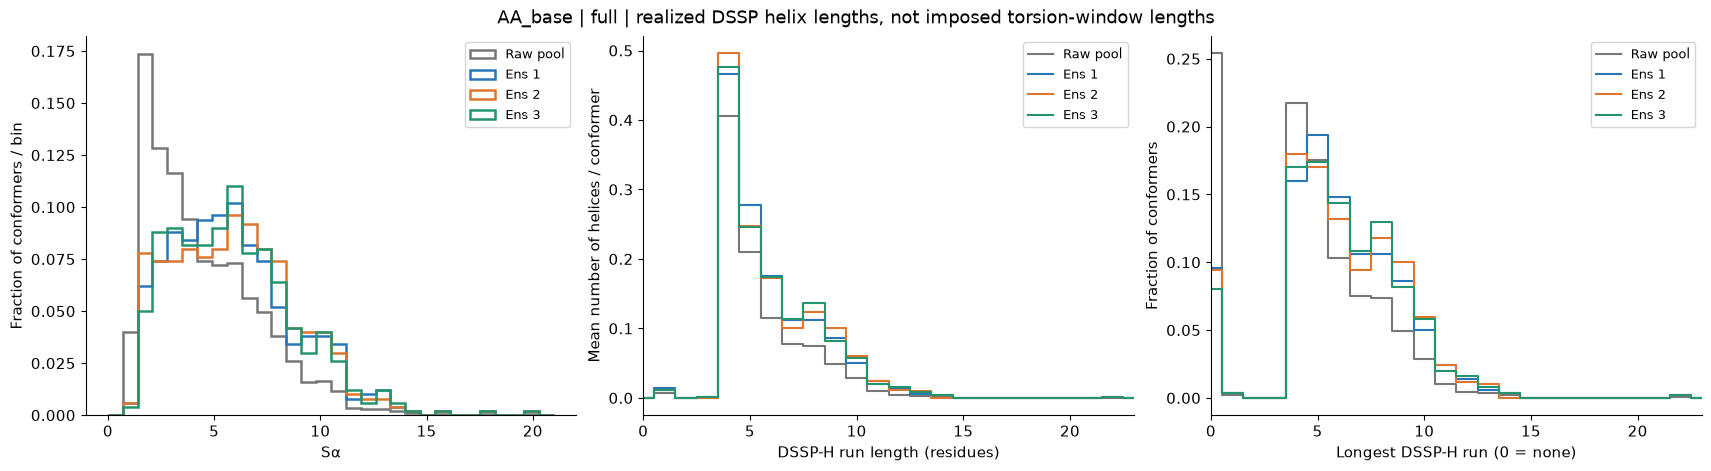

In [32]:
distributions("AA_base", "full")

### Sα and helix-length histograms: R2–R3 plus MD
Runs are clipped at segment boundaries. The Sα histogram is a fraction of conformers per common bin; all Sα values are included.

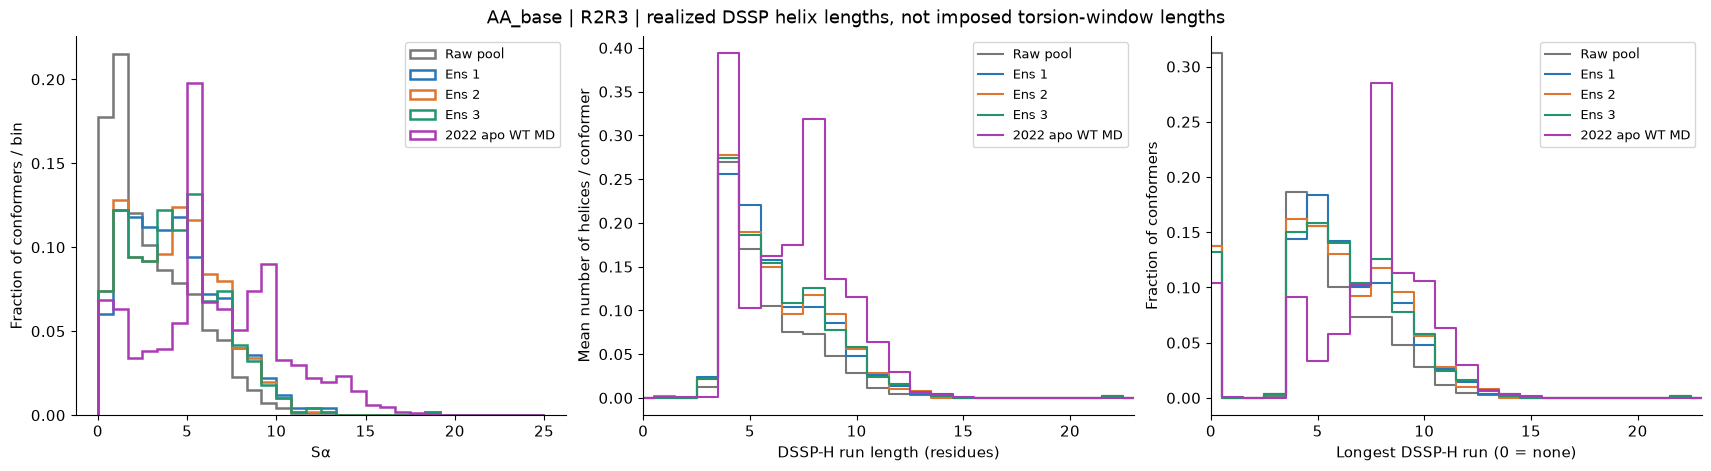

In [33]:
distributions("AA_base", "R2R3")

## AA expanded
Raw candidate pool versus all three 500-member selections. Ens1/2/3 correspond to optimizer seeds20260929/20261029/20261129. The MD comparator is always apo WT R2–R3, including in AA panels; it is not an AA simulation.

### SAXS before and after fitting
Each curve uses its own optimized nonnegative intensity scale; background is fixed to zero. Low-q slope annotations are diagnostic, not a separate restraint.

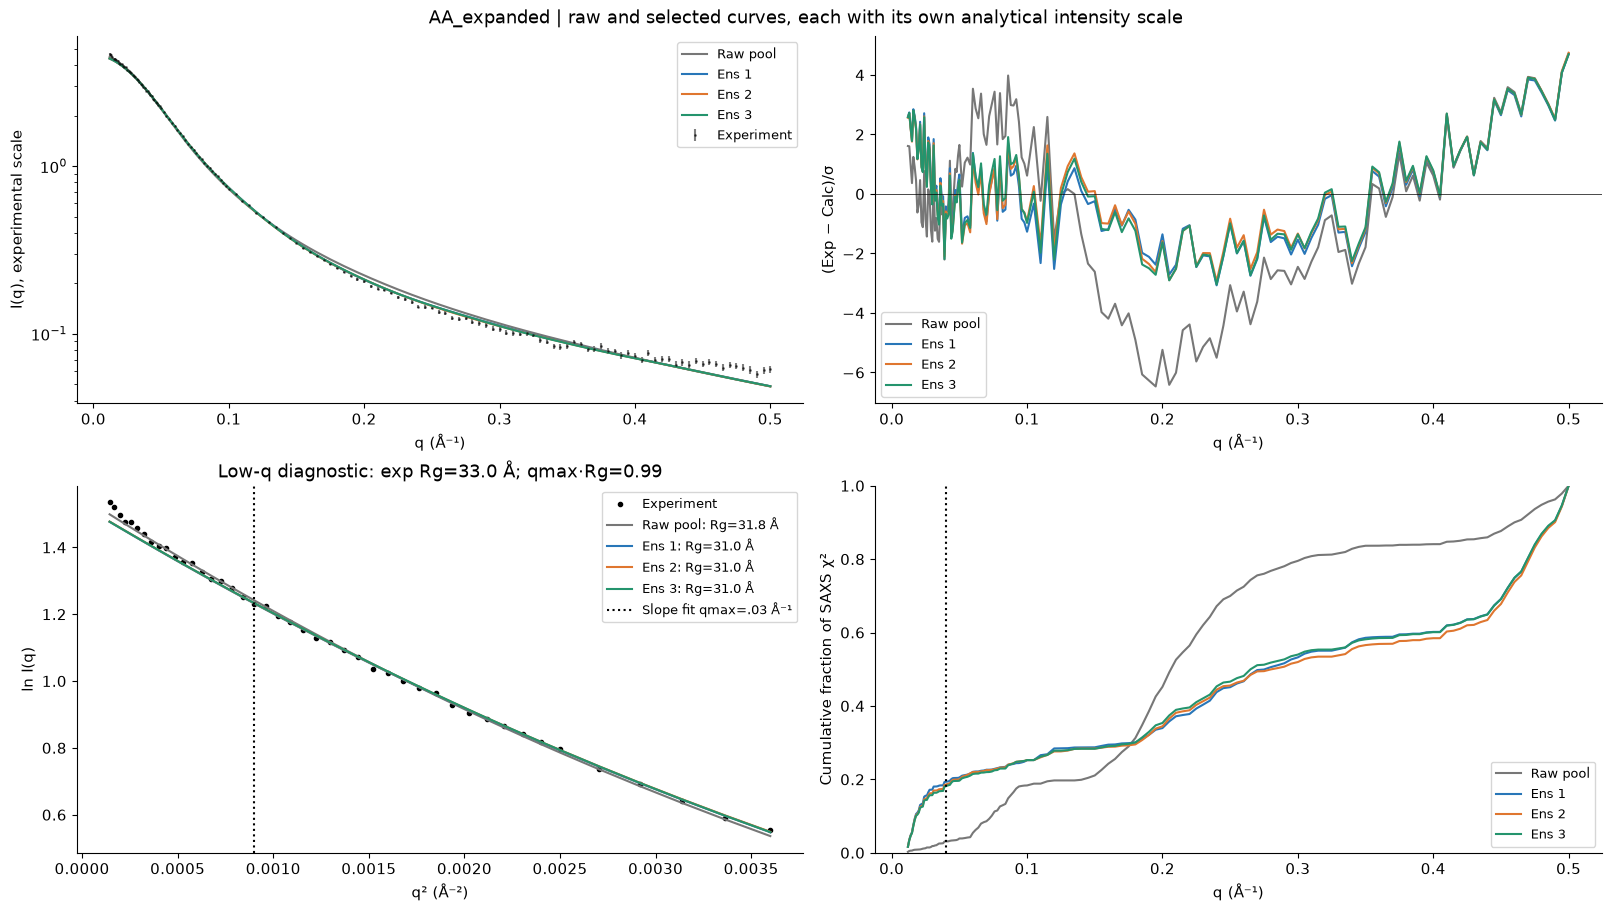

In [34]:
saxs("AA_expanded")

### Helix before and after selection
DSSP H and δ2D are distinct observables. Display excludes the added GP and terminal P447, as in earlier profiles. MD DSSP is calculated on the 56-residue core with caps excluded.

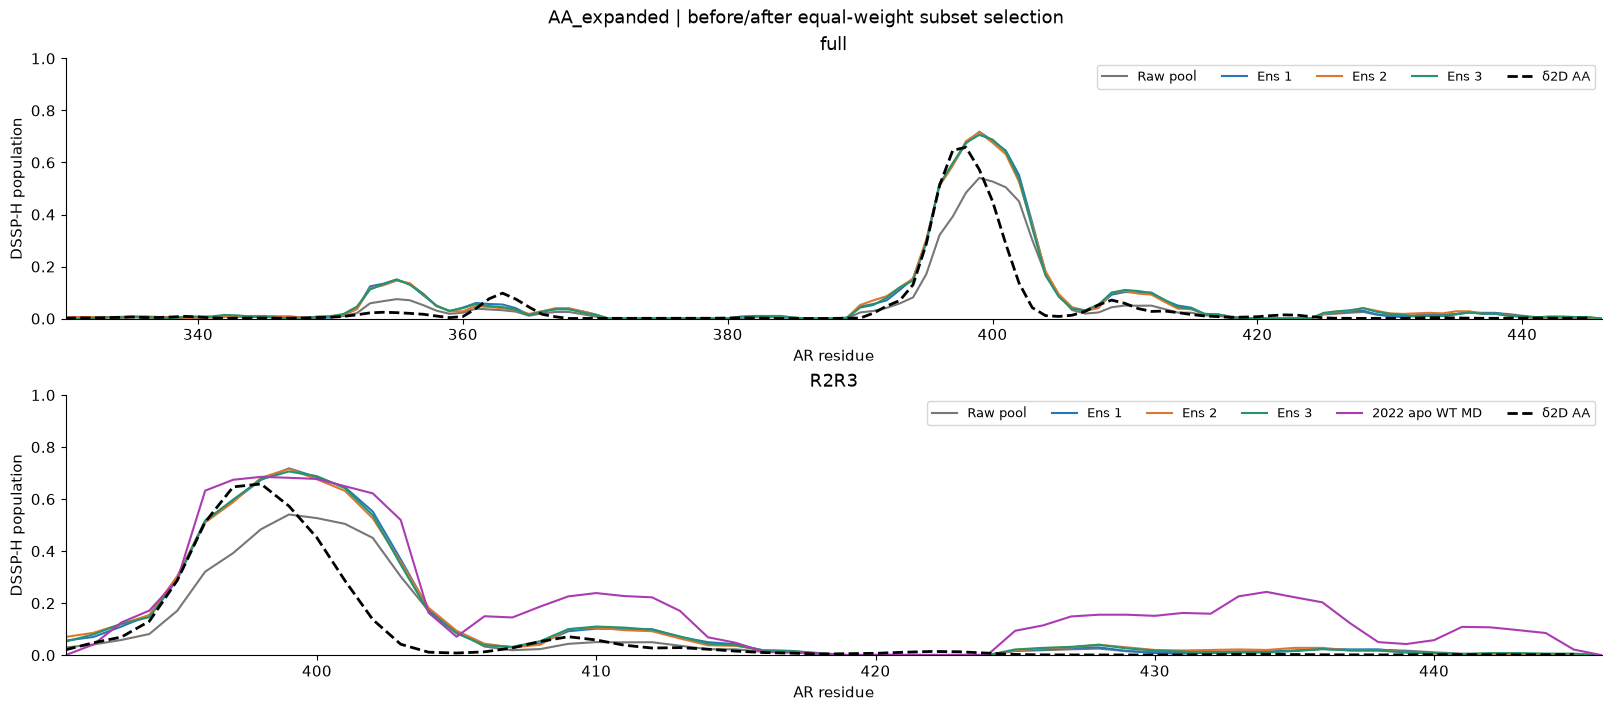

In [35]:
helicity("AA_expanded")

### Secondary shifts
Sequence-specific SPARTA+ random-coil shifts are subtracted from experiment and calculation. These comparisons include all available nuclei.

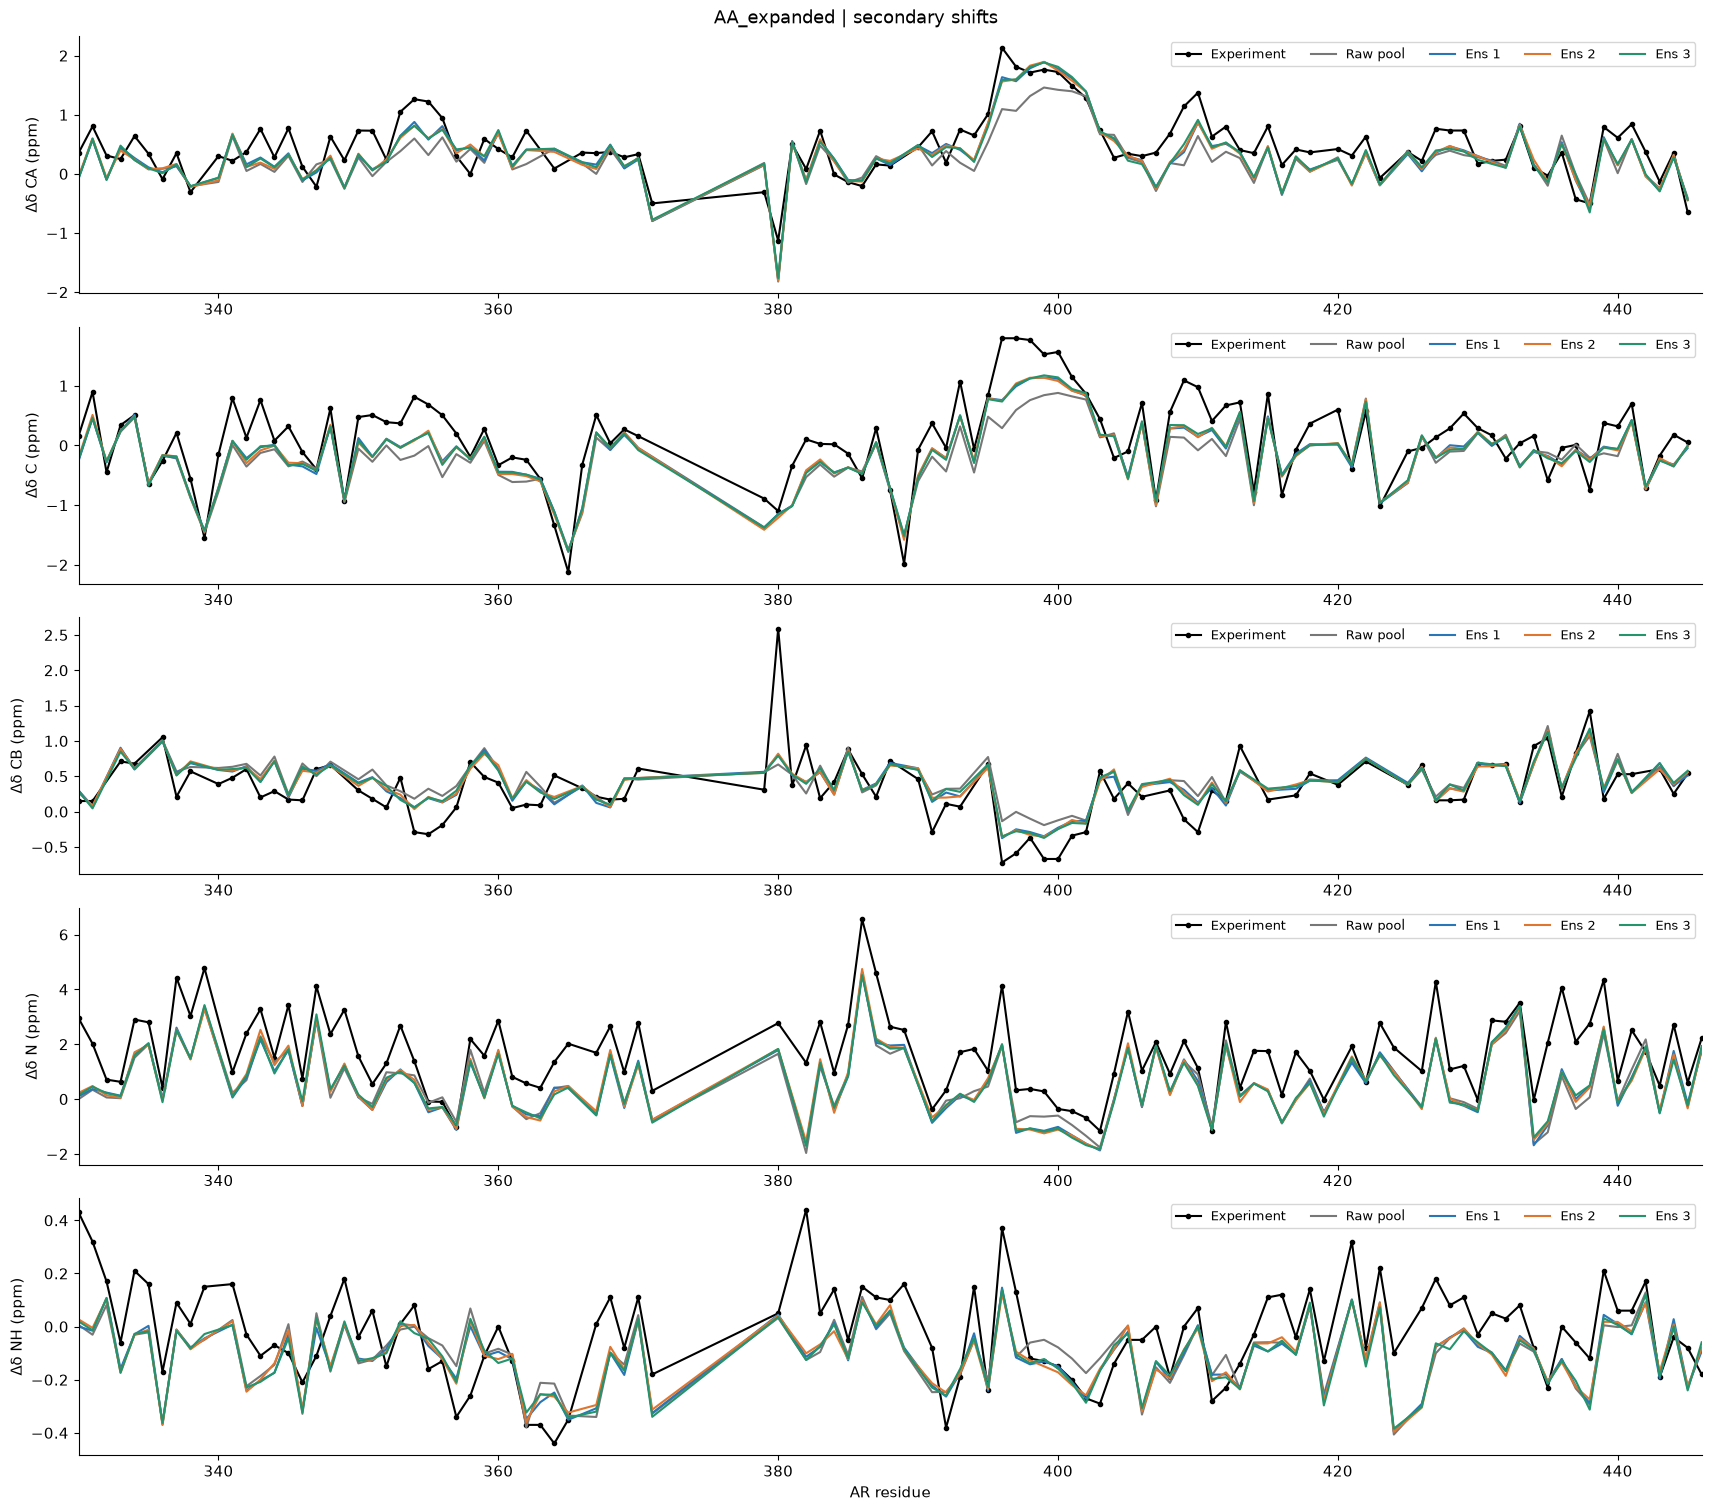

In [36]:
chemical_shifts("AA_expanded", secondary=True)

### CS residuals: signed and absolute
Each nucleus has separate signed and absolute bar panels. Residual = experiment − calculation; missing positions remain absent.

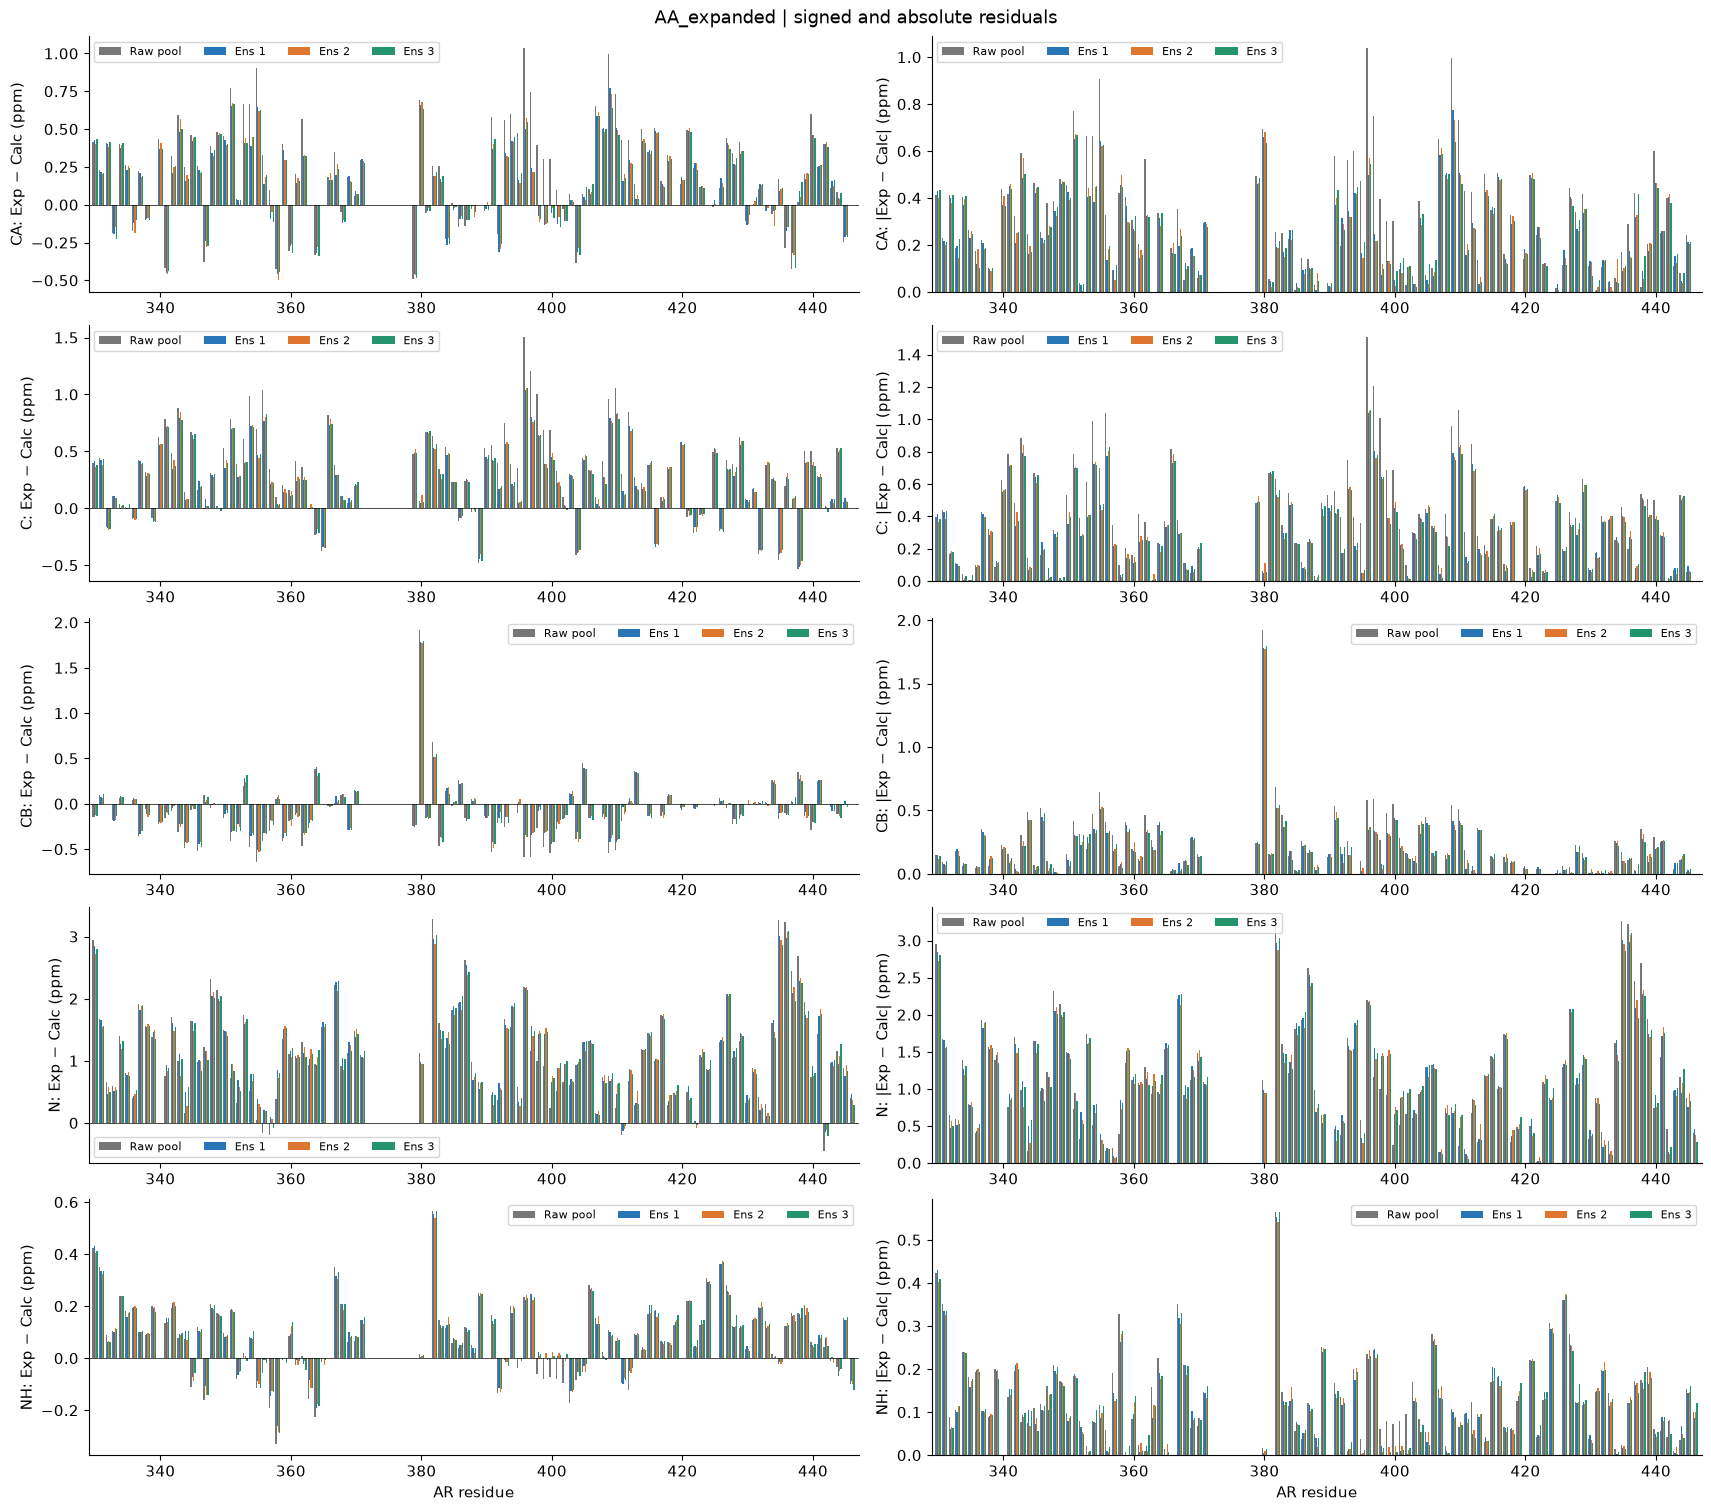

In [37]:
chemical_shifts("AA_expanded")

### Sα versus Rg: full chain
Original AR plotting transform: 30×30 density histogram, −0.001987×300×ln(density+10⁻⁶), Gaussian display interpolation, jet, color limits0.1–3.0. This is a sampling-density display, not a pool thermodynamic free energy.

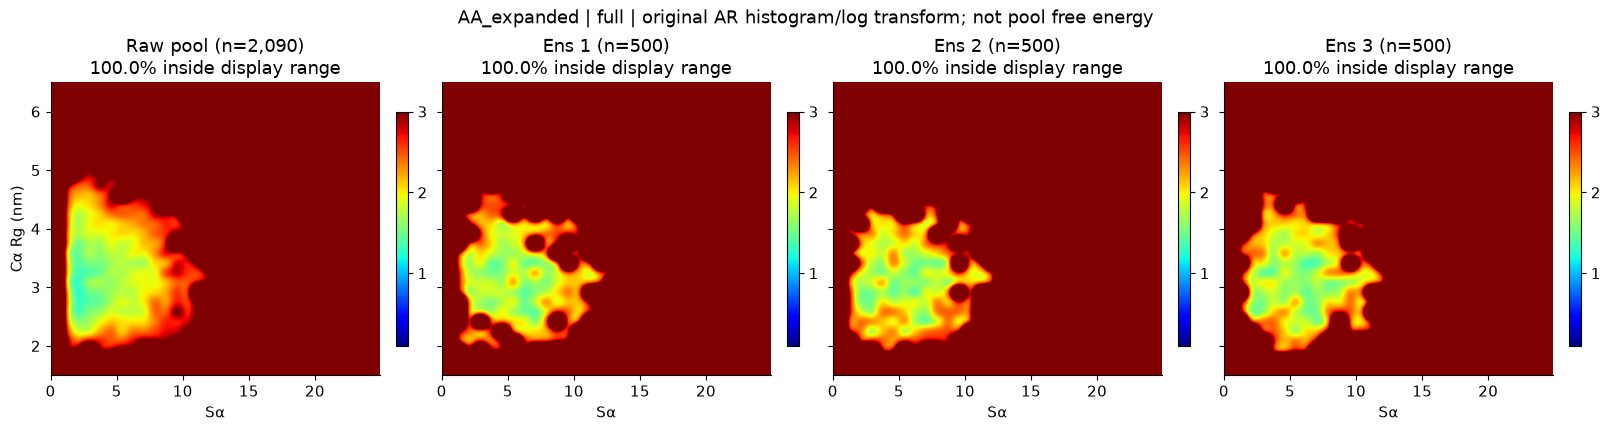

In [38]:
sa_rg("AA_expanded", "full")

### Sα versus Rg: matched R2–R3 plus MD
Original display range Sα0–25, Rg0.9–2.5nm. Panel titles report the retained fraction; histograms normalize within this window. Full statistics use all structures.

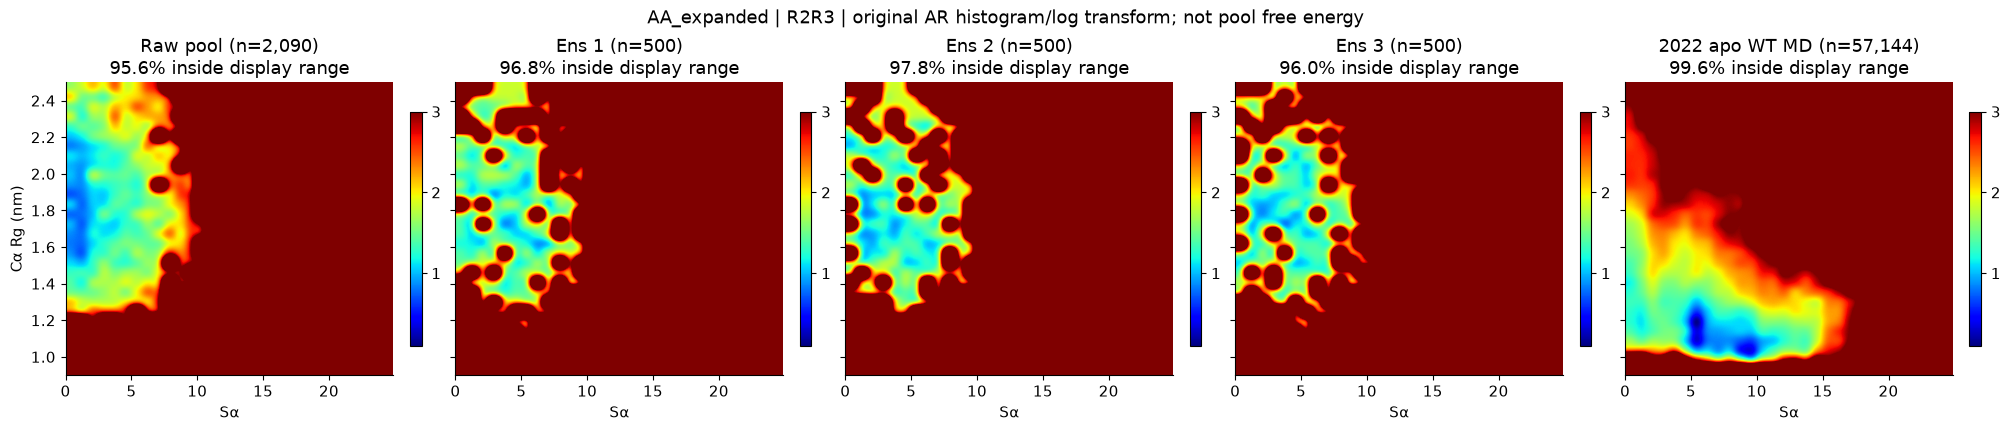

In [39]:
sa_rg("AA_expanded", "R2R3")

### Contact maps: full chain
Exact original closest-heavy cutoff1.2nm; diagonal zero and adjacent residues included. Shared probability scale0–1.

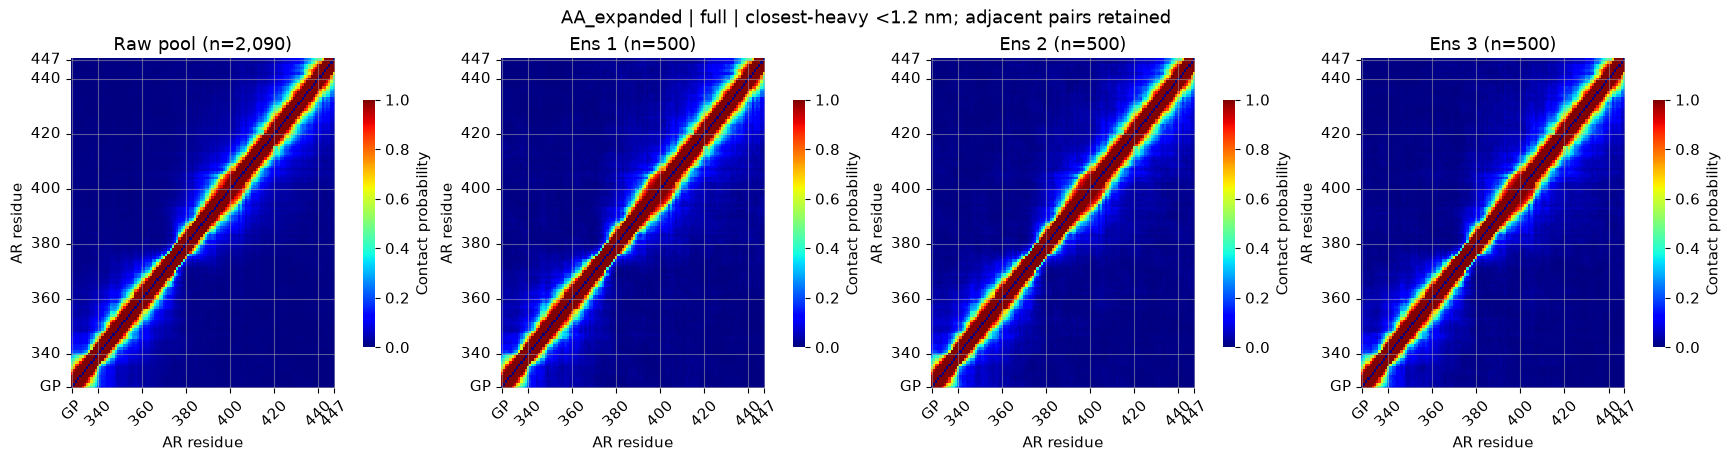

In [40]:
contacts("AA_expanded", "full")

### Contact maps: matched R2–R3 plus MD
Same AR391–446 segment. Current structures are cropped from full chains, whereas MD is a separately simulated capped short construct.

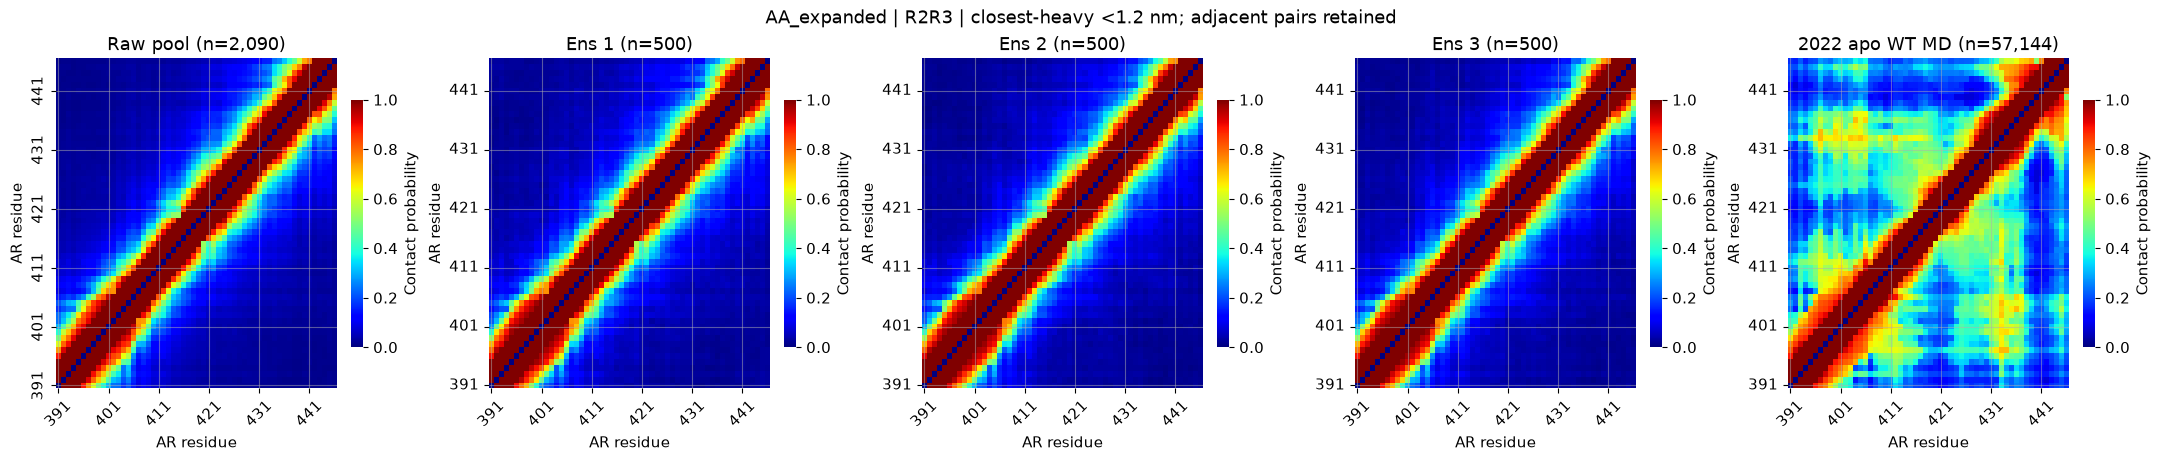

In [41]:
contacts("AA_expanded", "R2R3")

### Sα and helix-length histograms: full chain
Helix lengths are maximal contiguous DSSP-H runs. Middle panel: expected number of runs of each length per conformer, so helices/conformer can sum above one. Right panel includes longest length0 for conformers with no H run.

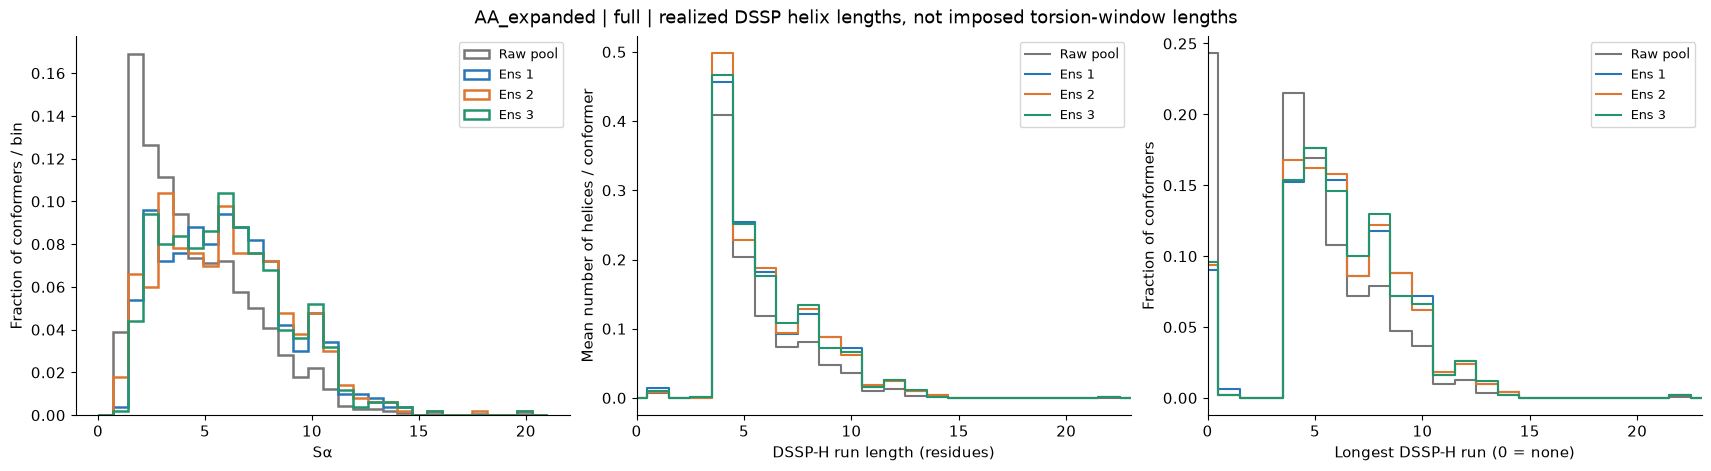

In [42]:
distributions("AA_expanded", "full")

### Sα and helix-length histograms: R2–R3 plus MD
Runs are clipped at segment boundaries. The Sα histogram is a fraction of conformers per common bin; all Sα values are included.

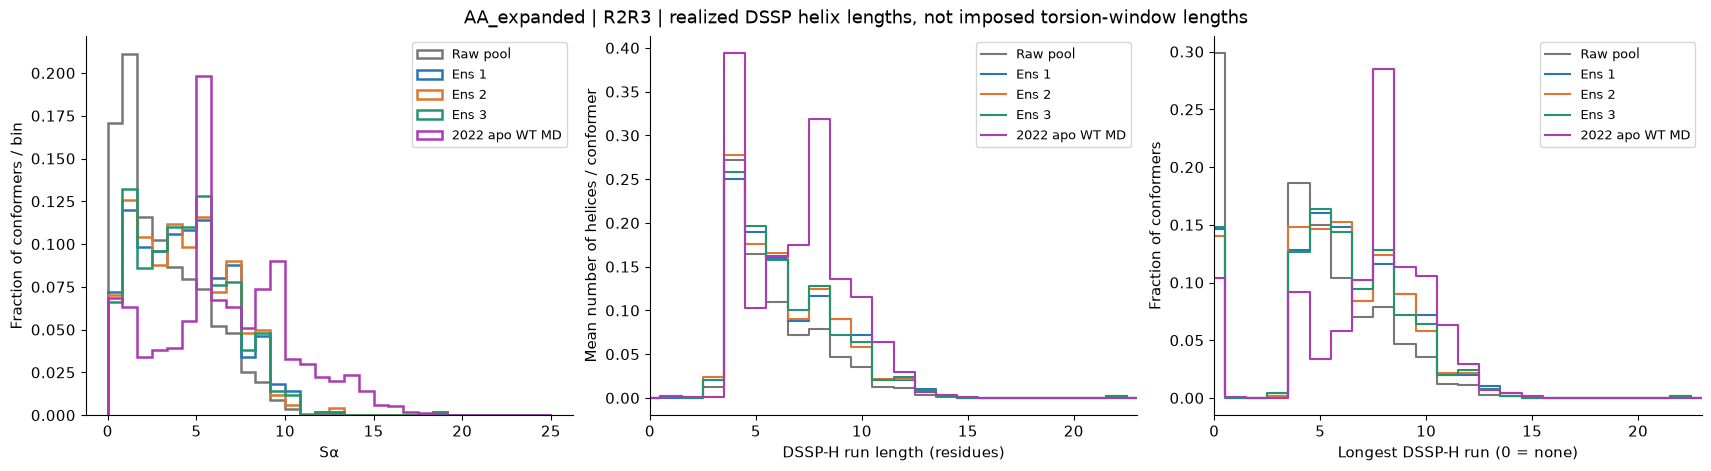

In [43]:
distributions("AA_expanded", "R2R3")

## Definitions and references
- [Original AR paper, Zhu et al. (2022)](https://doi.org/10.1038/s41467-022-34077-z); [analysis notebook](https://github.com/paulrobustelli/AR_ligand_binding); [trajectory archive](https://zenodo.org/records/7120845).
- [IDPConfGen](https://doi.org/10.1021/acs.jpca.2c03726), [δ2D](https://doi.org/10.1021/bi3001825), [SPARTA+](https://doi.org/10.1007/s10858-010-9433-9), [CRYSOL](https://doi.org/10.1107/S0021889895007047).
- [ASTEROIDS chemical shifts, Ozenne et al. (2012)](https://doi.org/10.1021/ja306905s); [NMR/SAXS ensemble selection, Schwalbe et al. (2014)](https://doi.org/10.1016/j.str.2013.10.020).

**Sα:** sum over seven-residue N/Cα/C/O windows of (1−(RMSD/0.10nm)^8)/(1−(RMSD/0.10nm)^12), with optimal rigid-body alignment; limit2/3 at RMSD0.10nm. The exact 50 original reference windows are used for AR391–446. Full-chain windows entirely within that segment use their matched references; outside it, the first seven-residue reference is the generic template. Thus full scores contain114 terms and cropped scores50; compare within a view.

**Contact means:** generated conformers use nonperiodic distances; original MD uses the periodic treatment of the original analysis. Full matrices were computed per candidate and subset-averaged; R2–R3 matrices are corresponding submatrices. These are broad proximity contacts, not a dedicated aromatic-stacking metric.

**Selection:** base pools2000; expanded WT2110/AA2090. Population100,1000 generations,500 distinct selected conformers. Shift scales0.10ppm carbon,0.50ppm nitrogen,0.20ppm HN/Hα. Only measured restraints available for each sequence are used. The final100 generations still improve the objective; contact/helix agreement across optimizer seeds is not proof of independently sampled ensemble convergence.

All source membership mappings and metrics are retained in `data/`. Charts are reproducible from those arrays; original trajectories are not embedded in the notebook.